In [3]:
# For data analysis and predictions
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, SimpleRNN, LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# For data visualize
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
csvData = pd.read_csv("./RawData/ADANIPORTS.csv", index_col=['Date'], parse_dates=['Date']);
df = pd.DataFrame(csvData);
df = df.drop(columns=['Trades', 'Series', 'Symbol']);

In [5]:
# display the columns in dataframe
print(df.columns);

# display how many data in csv file (row, column)
print(df.shape);

Index(['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume',
       'Turnover', 'Deliverable Volume', '%Deliverble'],
      dtype='object')
(3322, 11)


In [6]:
# display the variable types of column
print(df.dtypes);

Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Deliverable Volume      int64
%Deliverble           float64
dtype: object


In [7]:
print(df.head());

            Prev Close    Open     High    Low   Last   Close    VWAP  \
Date                                                                    
2007-11-27      440.00  770.00  1050.00  770.0  959.0  962.90  984.72   
2007-11-28      962.90  984.00   990.00  874.0  885.0  893.90  941.38   
2007-11-29      893.90  909.00   914.75  841.0  887.0  884.20  888.09   
2007-11-30      884.20  890.00   958.00  890.0  929.0  921.55  929.17   
2007-12-03      921.55  939.75   995.00  922.0  980.0  969.30  965.65   

              Volume      Turnover  Deliverable Volume  %Deliverble  
Date                                                                 
2007-11-27  27294366  2.687719e+15             9859619       0.3612  
2007-11-28   4581338  4.312765e+14             1453278       0.3172  
2007-11-29   5124121  4.550658e+14             1069678       0.2088  
2007-11-30   4609762  4.283257e+14             1260913       0.2735  
2007-12-03   2977470  2.875200e+14              816123       0.2741 

In [8]:
print(df.describe());

        Prev Close         Open         High          Low         Last  \
count  3322.000000  3322.000000  3322.000000  3322.000000  3322.000000   
mean    344.114314   344.763019   351.608007   337.531969   344.239539   
std     192.936882   193.619992   198.617808   188.676614   193.187813   
min     108.000000   108.000000   110.450000   105.650000   108.000000   
25%     164.312500   164.850000   168.000000   161.600000   164.075000   
50%     324.700000   325.750000   331.275000   319.850000   325.000000   
75%     400.912500   401.000000   407.187500   395.000000   400.912500   
max    1307.450000  1310.250000  1324.000000  1270.000000  1308.000000   

             Close         VWAP        Volume      Turnover  \
count  3322.000000  3322.000000  3.322000e+03  3.322000e+03   
mean    344.201626   344.853182  2.954564e+06  1.070144e+14   
std     193.045886   193.841305  4.104227e+06  2.625564e+14   
min     108.000000   108.340000  1.236600e+04  2.415857e+11   
25%     164.312500

In [9]:
print(df);

            Prev Close    Open     High     Low   Last   Close    VWAP  \
Date                                                                     
2007-11-27      440.00  770.00  1050.00  770.00  959.0  962.90  984.72   
2007-11-28      962.90  984.00   990.00  874.00  885.0  893.90  941.38   
2007-11-29      893.90  909.00   914.75  841.00  887.0  884.20  888.09   
2007-11-30      884.20  890.00   958.00  890.00  929.0  921.55  929.17   
2007-12-03      921.55  939.75   995.00  922.00  980.0  969.30  965.65   
...                ...     ...      ...     ...    ...     ...     ...   
2021-04-26      725.35  733.00   739.65  728.90  729.2  730.75  733.25   
2021-04-27      730.75  735.00   757.50  727.35  748.6  749.15  747.67   
2021-04-28      749.15  755.00   760.00  741.10  743.4  746.25  751.02   
2021-04-29      746.25  753.20   765.85  743.40  746.4  746.75  753.06   
2021-04-30      746.75  739.00   759.45  724.50  726.4  730.05  743.35   

              Volume      Turnover  D

In [10]:
# function for box plot
def plot_boxplot(data, column):
    sns.boxplot(data=data, x=column);
    sns.despine();
    plt.title(f"Boxplot of {column}");
    plt.show();
    
# Define function to plot correlation heatmap
def plot_heatmap(data, title):
    sns.heatmap(data.corr(), cmap='coolwarm', annot=True);
    plt.title(title);
    sns.despine();
    plt.show();

# function for plot pair plot
def plot_pairplot(data, columns):
    sns.pairplot(data=data, vars=columns);
    sns.despine();
    plt.show();

def plot_timeSeries(dataframe, columns):
    for column in columns: 
        plt.figure(figsize=(16, 4));
        plt.plot(dataframe[column]);
        plt.title(f'{column} of Adani ports stock data');
        plt.ylabel(f"{column}");
        plt.xlabel('Trading Year');
        plt.grid(False);
        plt.show();

In [11]:
# All the data relate to stock price
priceData = ['Prev Close', 'Open', 'High', 'Low', 'Close', 'VWAP'];

# All the data relate to stock volume
volumeData = ['Volume', 'Turnover', 'Deliverable Volume', '%Deliverble'];

# Normalize data 
All_Columns = priceData + volumeData;

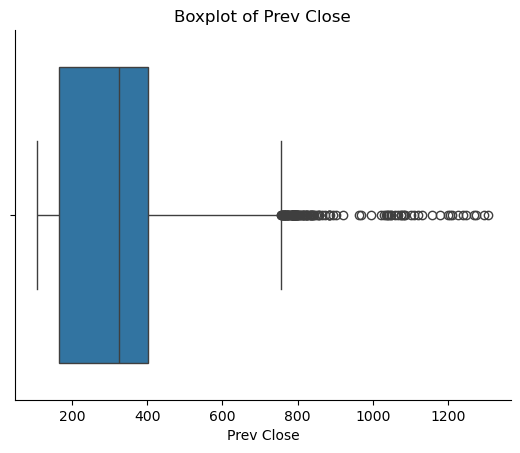

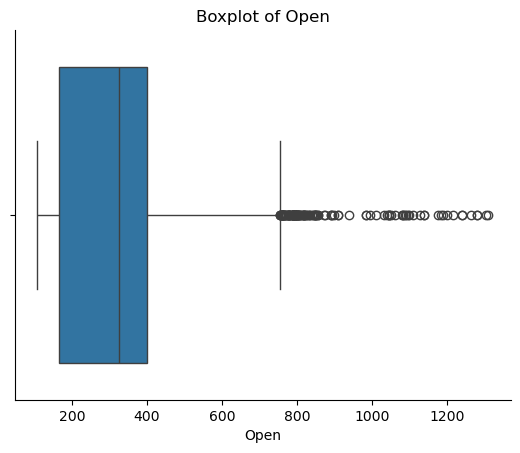

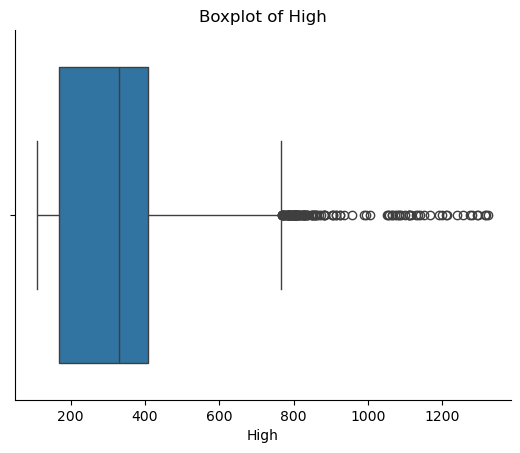

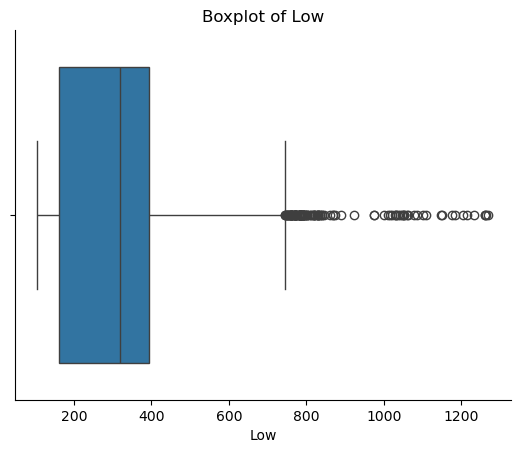

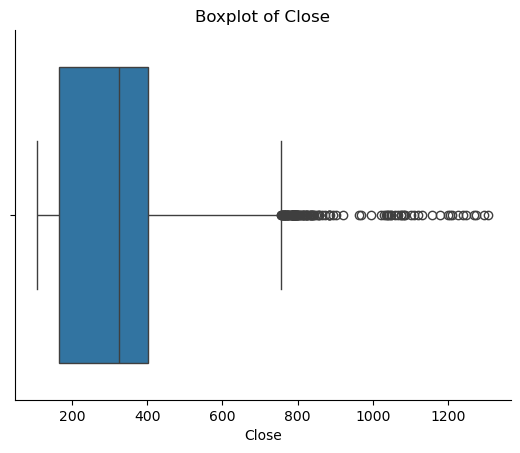

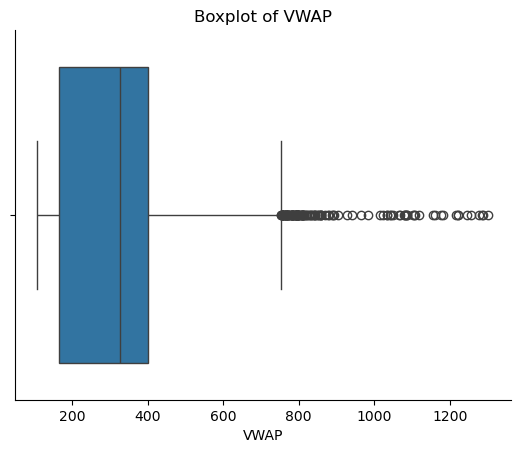

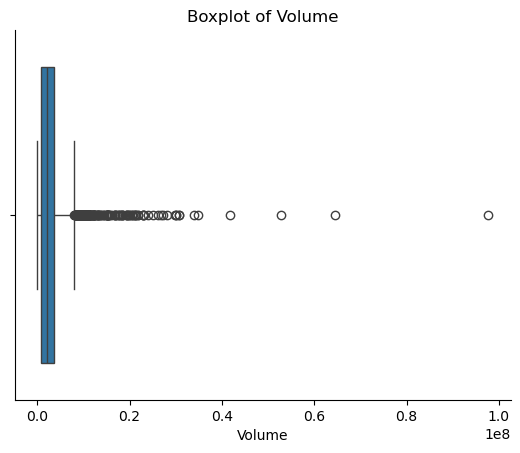

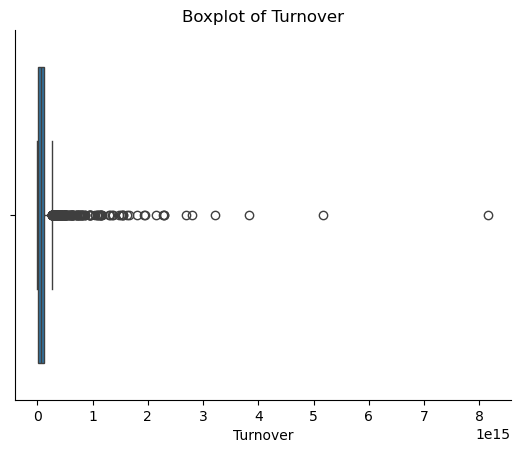

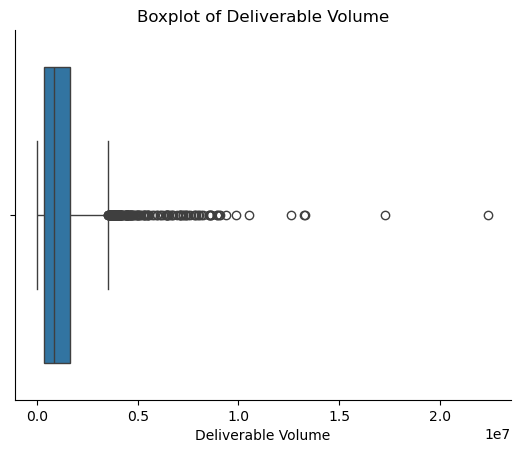

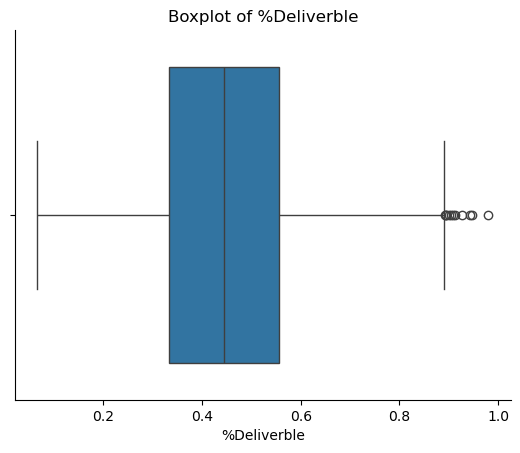

In [12]:
# Loop through each column to plot boxplots 
for column in All_Columns: 
    plot_boxplot(df, column);

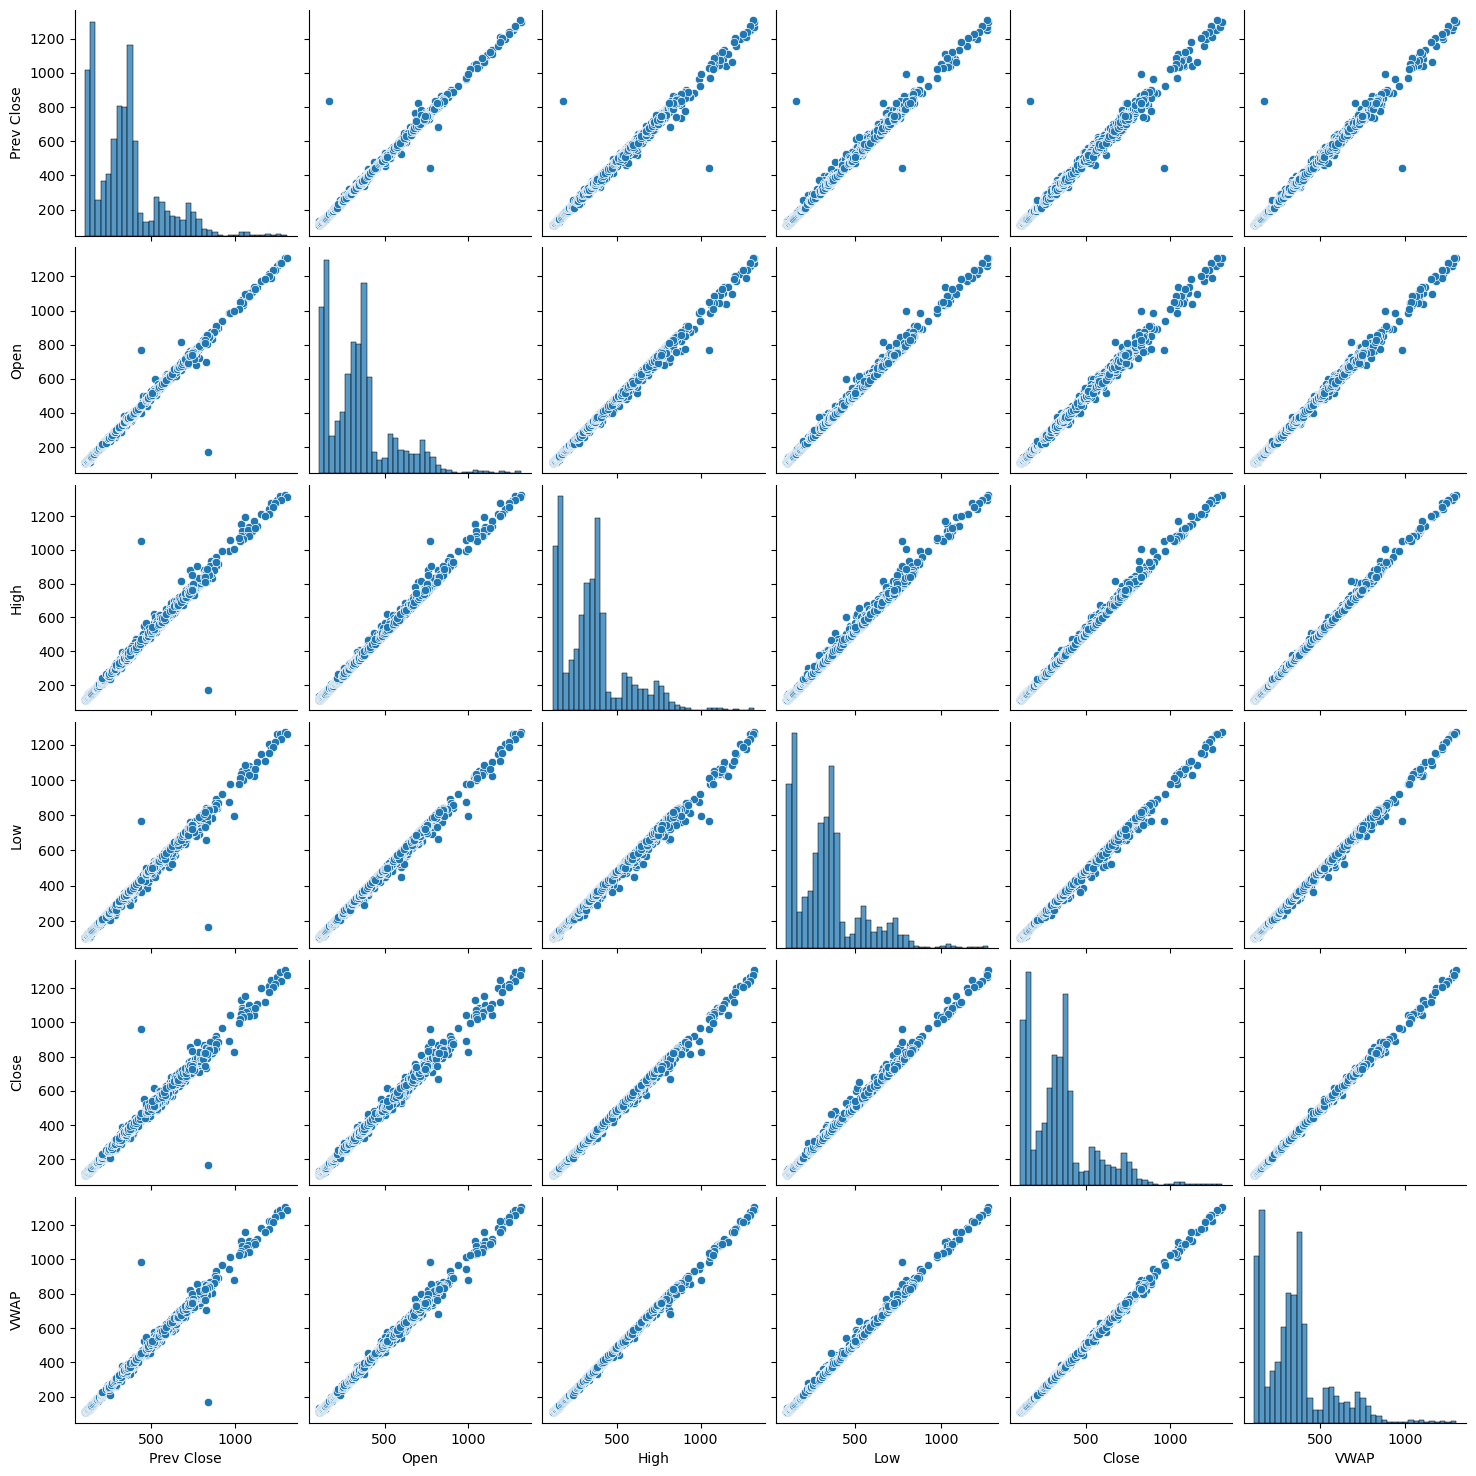

In [13]:
# For price data
plot_pairplot(df, priceData);

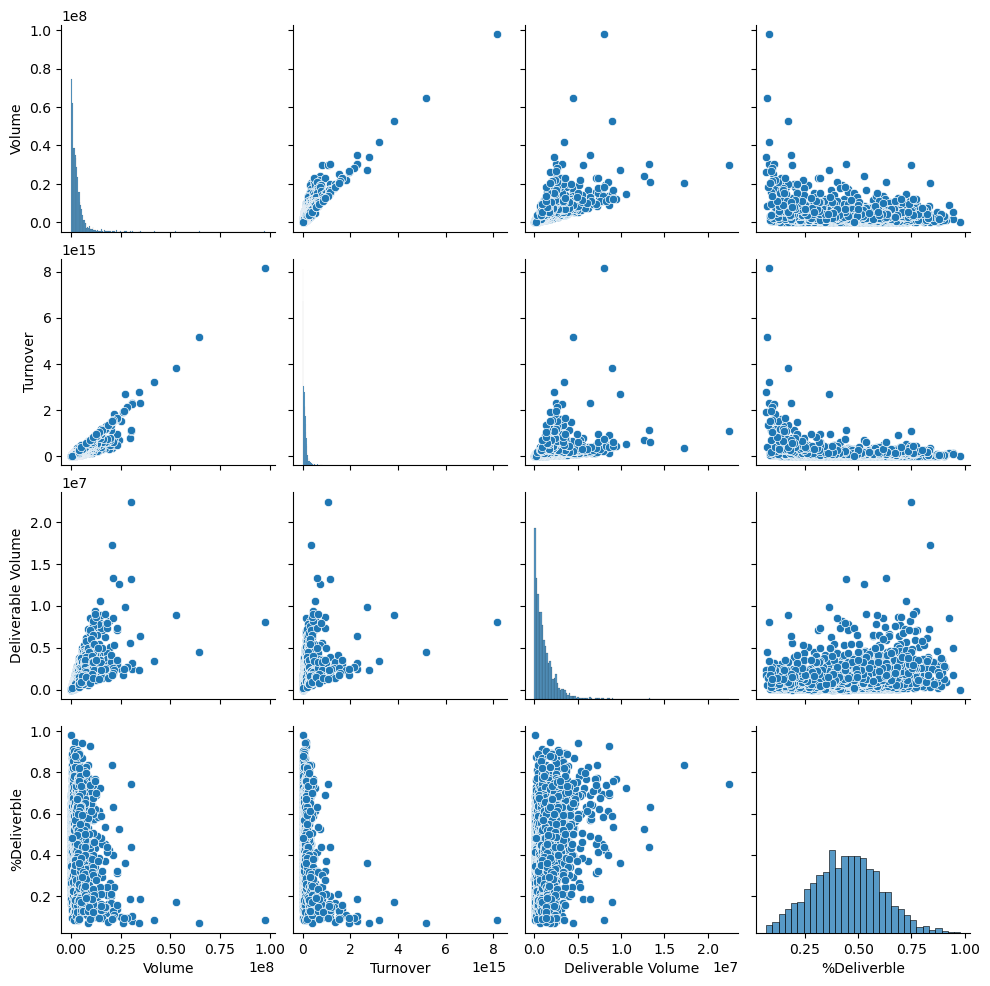

In [14]:
# For volume data
plot_pairplot(df, volumeData);

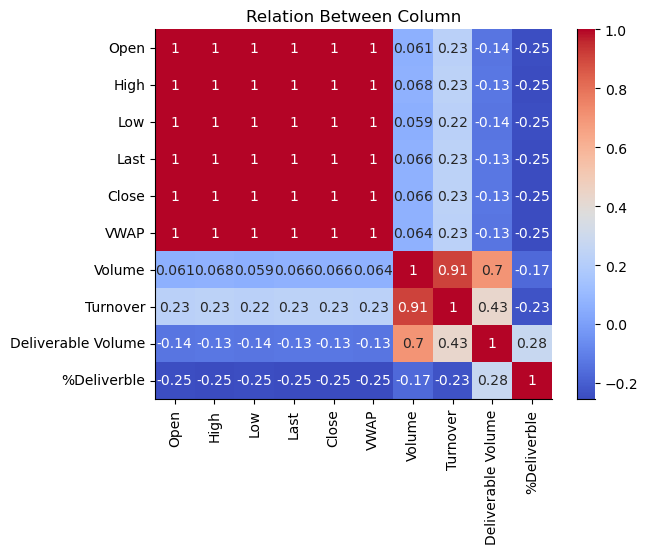

In [15]:
plot_heatmap(df.iloc[:,1:], 'Relation Between Column');

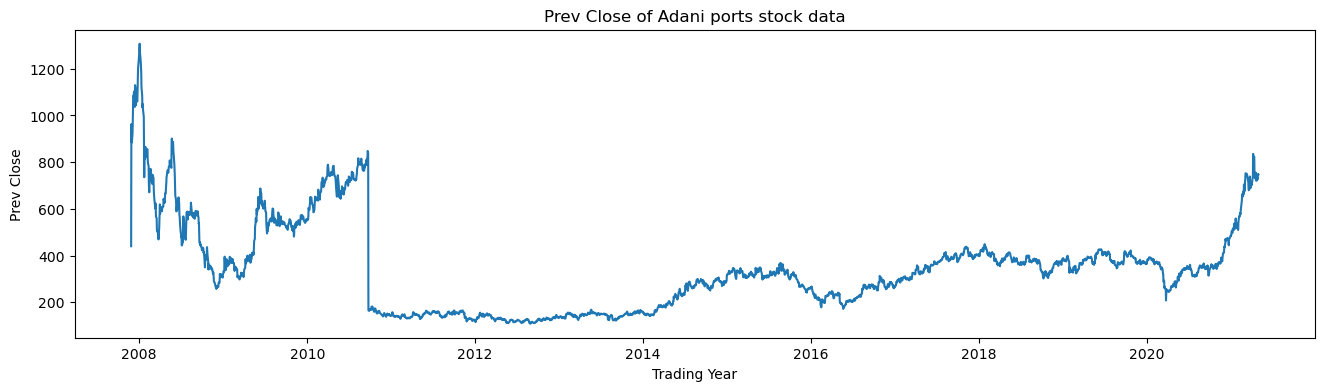

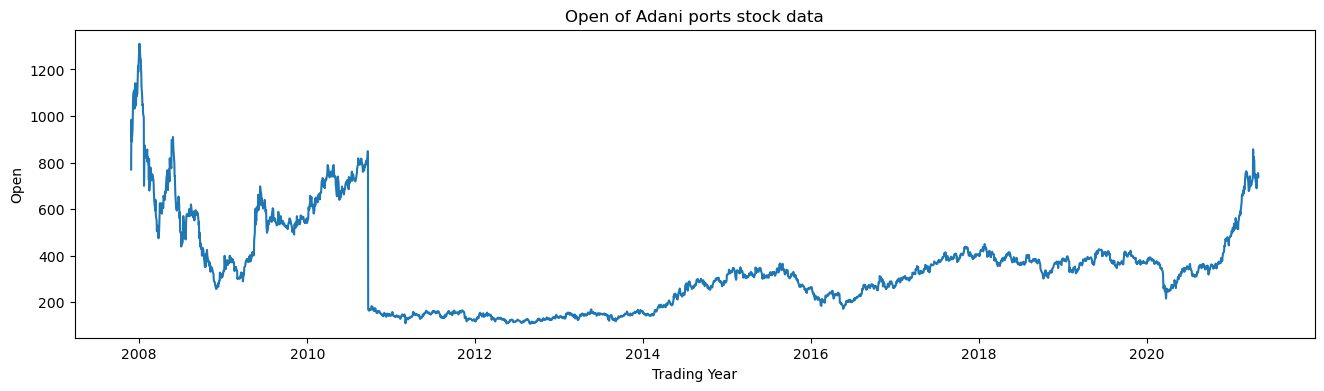

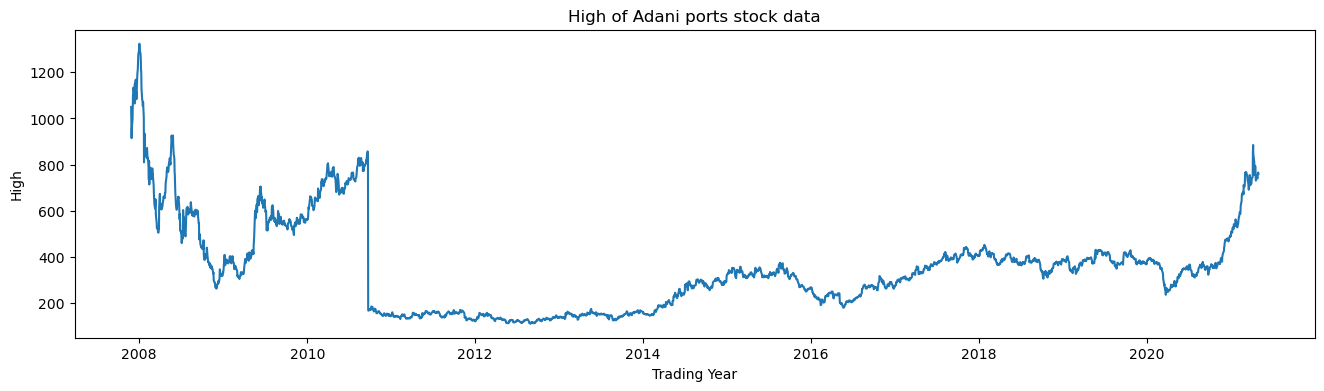

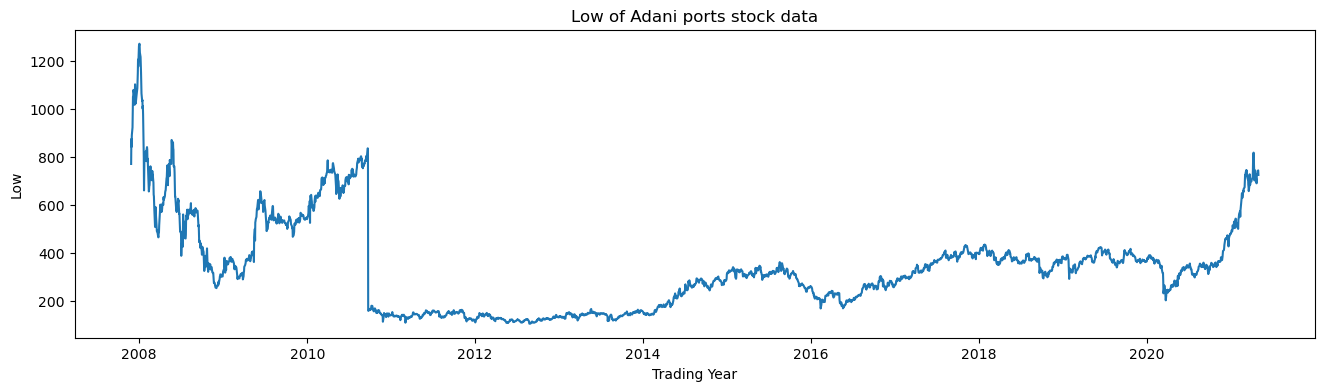

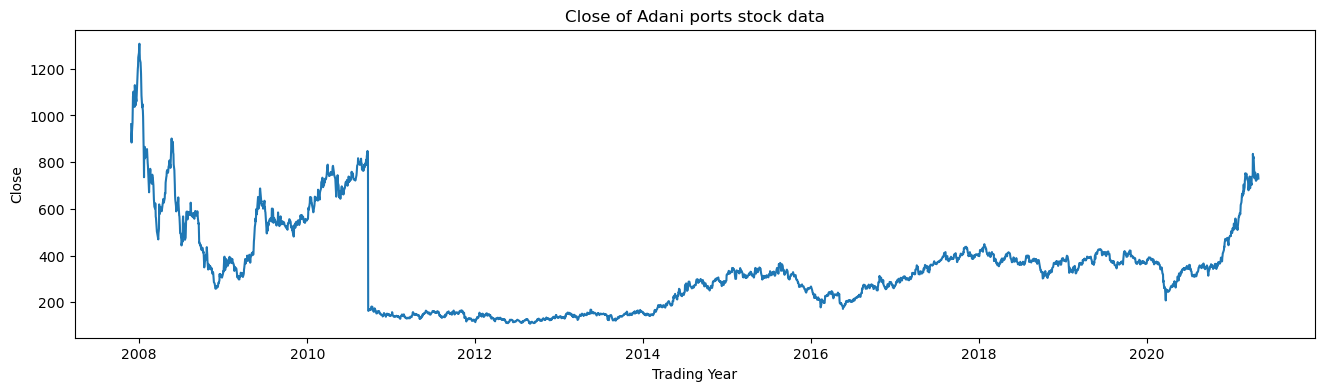

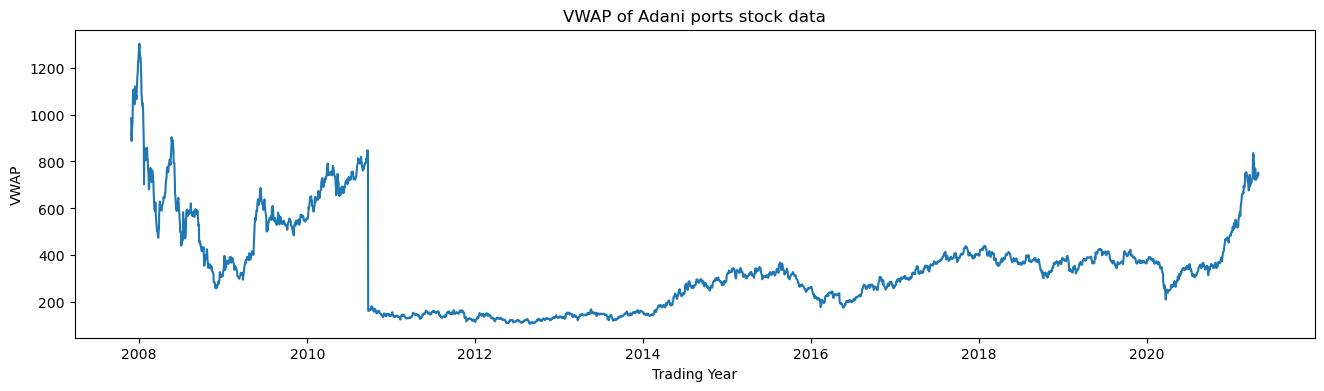

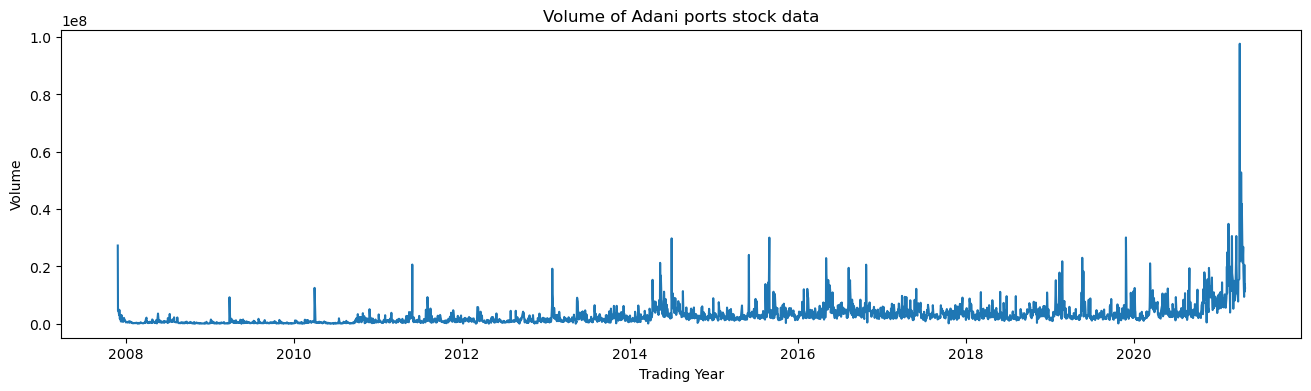

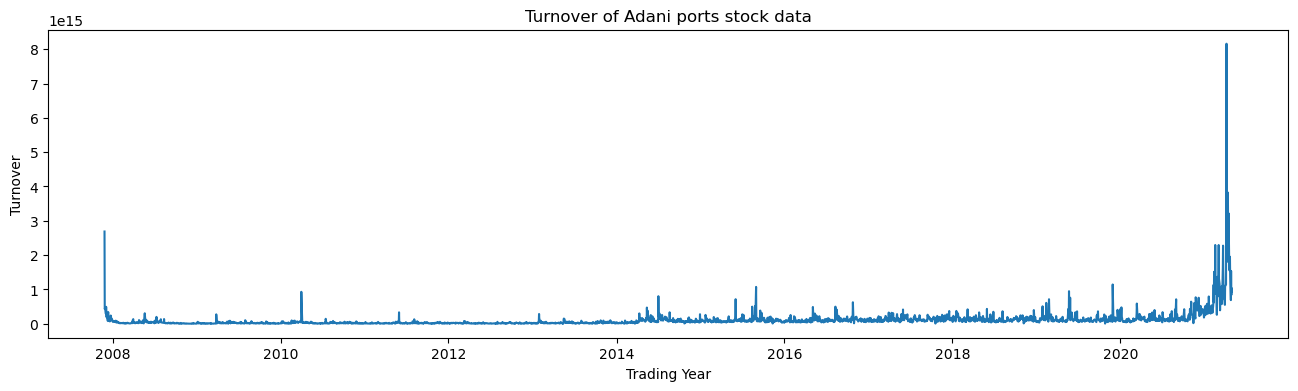

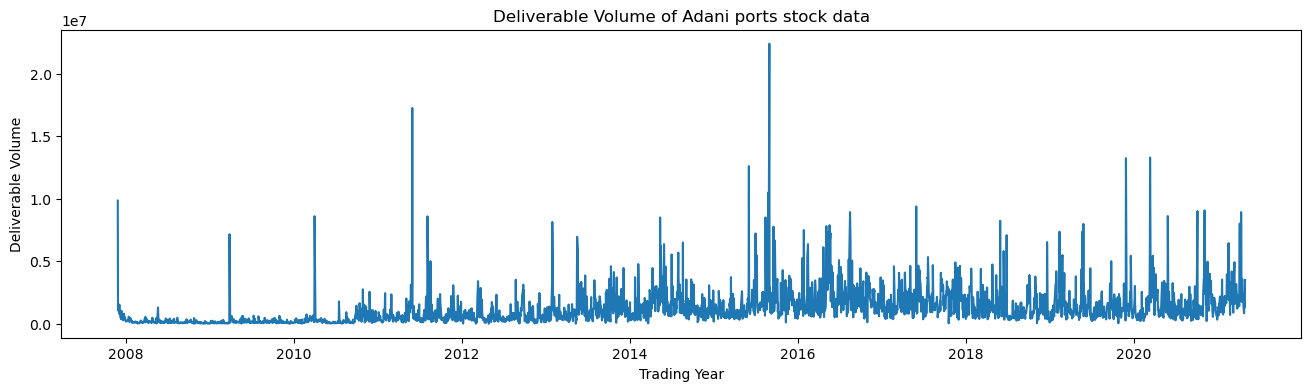

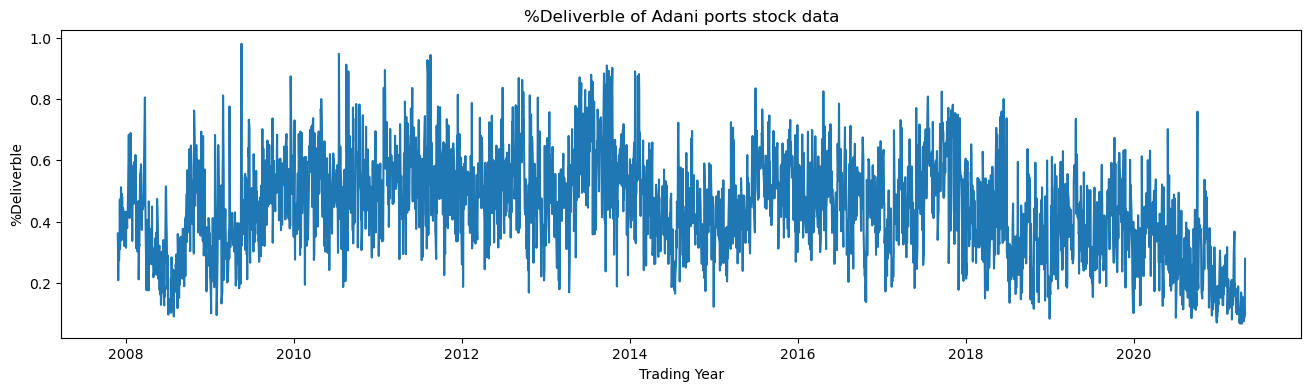

In [16]:
# print all data time series
plot_timeSeries(df, All_Columns);

In [17]:
# Scaling the data based on highest and lowest value
scaler = MinMaxScaler();
scaled_data = scaler.fit_transform(df[All_Columns]);
scaled_df = pd.DataFrame(scaled_data, columns=All_Columns, index=df.index);
print(scaled_df.head());

            Prev Close      Open      High       Low     Close      VWAP  \
Date                                                                       
2007-11-27    0.276794  0.550634  0.774216  0.570576  0.712743  0.734103   
2007-11-28    0.712743  0.728634  0.724774  0.659896  0.655217  0.697799   
2007-11-29    0.655217  0.666251  0.662766  0.631554  0.647130  0.653161   
2007-11-30    0.647130  0.650447  0.698406  0.673638  0.678269  0.687572   
2007-12-03    0.678269  0.691828  0.728895  0.701121  0.718079  0.718129   

              Volume  Turnover  Deliverable Volume  %Deliverble  
Date                                                             
2007-11-27  0.279227  0.329318            0.439703     0.322305  
2007-11-28  0.046763  0.052818            0.064606     0.274102  
2007-11-29  0.052318  0.055733            0.047490     0.155346  
2007-11-30  0.047054  0.052456            0.056023     0.226227  
2007-12-03  0.030347  0.035202            0.036176     0.226884  


In [18]:
# Function to labeling data
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data)- seq_length):
        sequences.append(data[i:i + seq_length]);
        labels.append(data[i + seq_length]);
    return np.array(sequences), np.array(labels);

# To scaling the data with MinMaxScalerA
def inverse_transform_predictions(predictions): 
    return scaler.inverse_transform(predictions);

# Print the top 5 rows predictions data  
def printShapeResult(df):
    print("Predicted Results:");
    print(predictions_df.head());
    print(predictions_df.shape);

#It used to print Time Series plot with predict dataframe and actual dataframe
def TimeSeriesPlot(Model, column, predictDF):
    # these part are used to combine actual data and predict data
    comparison_df = pd.DataFrame({ 
        'Actual': actual_last_20[column].values, 
        'Predicted': predictDF[column].values 
    }, index=actual_last_20.index);
    
    # Plot actual and predicted values
    plot_time_series(comparison_df['Actual'], comparison_df['Predicted'], f"{column} - Actual vs Predicted ({Model})");

# Plot actual and predicted values
def plot_time_series(actual_series, predicted_series, title): 
    plt.figure(figsize=(16, 6));
    plt.plot(actual_series.index, actual_series, label='Actual');
    plt.plot(predicted_series.index, predicted_series, linestyle='--', label='Predicted');
    plt.title(title);
    plt.xlabel('Date');
    plt.ylabel('Value');
    plt.legend(loc='best');
    plt.grid(True);
    plt.show();

def plot_time_series_all(actual_series, model_data_map, column, best_model_name):
    plt.figure(figsize=(16, 6))
    plt.plot(actual_series.index, actual_series, label='Actual', color='black')
    
    for model_name, model_series in model_data_map.items():
        if model_name == best_model_name:
            plt.plot(model_series.index, model_series, linestyle='--', linewidth=2.5, label=f'{model_name} (Best)', color='red')
        else:
            plt.plot(model_series.index, model_series, linestyle='--', alpha=0.5, label=model_name)
    
    plt.title(f"{column} - Actual vs Predicted (Best: {best_model_name})")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    plt.show();

In [19]:
# Define sequence length 
seq_length = 60;

# Create sequences 
sequences, labels = create_sequences(scaled_df.values, seq_length);

In [20]:
# Split data as 80 for training/20 for testing
num_training_samples = int(0.8 * len(sequences));
X_train, X_test = sequences[:num_training_samples], sequences[num_training_samples:];
y_train, y_test = labels[:num_training_samples], sequences[num_training_samples:];

print(f"Training sequences shape: {X_train.shape}");
print(f"Training labels shape: {y_train.shape}");
print(f"Testing sequences shape: {X_test.shape}");
print(f"Testing labels shape: {y_test.shape}")

Training sequences shape: (2609, 60, 10)
Training labels shape: (2609, 10)
Testing sequences shape: (653, 60, 10)
Testing labels shape: (653, 60, 10)


In [21]:
# Capture last 20% of data for compare the predict result 
num_samples = len(X_test)
actual_last_20 = df.iloc[-num_samples: -1] 

# Callbacks defination
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True);

In [22]:
# Using LSTM(Long Short Term Model);alogrithm to predict
model = Sequential();
model.add(Input(shape=(seq_length, len(All_Columns))));
model.add(LSTM(100, return_sequences=True, kernel_regularizer='l2'));
model.add(Dropout(0.3));
model.add(LSTM(100, kernel_regularizer='l2'));
model.add(Dropout(0.3));
model.add(Dense(len(All_Columns)));
optimizer = Adam(learning_rate=0.001);

#Compile and fit the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae']);
model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping]);

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.2438 - mae: 0.0888 - val_loss: 0.2242 - val_mae: 0.0295
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1424 - mae: 0.0523 - val_loss: 0.0206 - val_mae: 0.0347
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0173 - mae: 0.0527 - val_loss: 0.0059 - val_mae: 0.0351
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0072 - mae: 0.0460 - val_loss: 0.0045 - val_mae: 0.0297
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0064 - mae: 0.0452 - val_loss: 0.0045 - val_mae: 0.0320
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0066 - mae: 0.0449 - val_loss: 0.0050 - val_mae: 0.0401
Epoch 7/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0063 - mae: 0.0454 - val_loss: 0.0042 - val_mae: 0.0306
Epoch 8/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0058 - mae: 0.0416 - val_loss: 0.0045 - val_mae: 0.0362
Epoch 9/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - lo

In [23]:
# Make predictions and inverse transform 
predictions = model.predict(X_test);
predictions = inverse_transform_predictions(predictions);

# Convert predictions to DataFrame 
predictions_df = pd.DataFrame(predictions, columns=All_Columns, index=df.index[-len(predictions):]);

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [24]:
# Print LSTM predict result
printShapeResult(predictions_df);

Predicted Results:
            Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  394.727722  394.919952  403.776123  384.908813  397.092346   
2018-09-07  394.433411  394.611816  403.518372  384.661804  396.899597   
2018-09-10  394.338196  394.507172  403.448944  384.613708  396.892181   
2018-09-11  394.371674  394.537018  403.487061  384.688782  396.987701   
2018-09-12  394.460388  394.627777  403.561707  384.810486  397.109955   

                  VWAP      Volume      Turnover  Deliverable Volume  \
Date                                                                   
2018-09-06  395.534515  2397151.75  7.064347e+13         1113669.250   
2018-09-07  395.232544  2399971.50  7.060131e+13         1114792.125   
2018-09-10  395.135773  2402111.75  7.056206e+13         1115613.375   
2018-09-11  395.169159  2403519.00  7.053111e+13         1116229.125   
2018-09-12  395.258484  240431

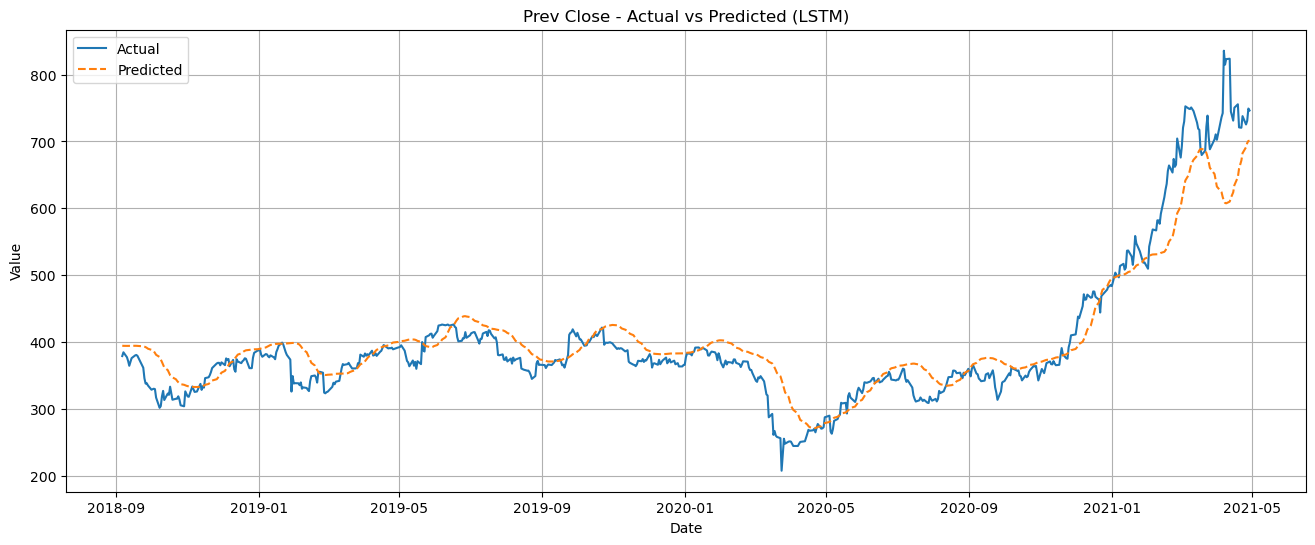

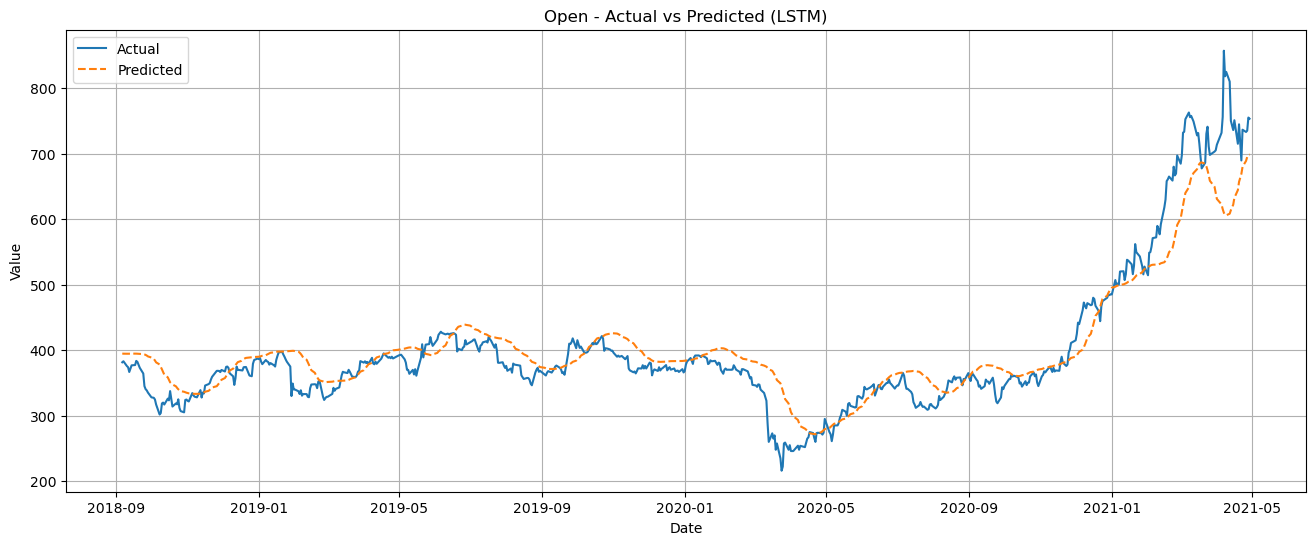

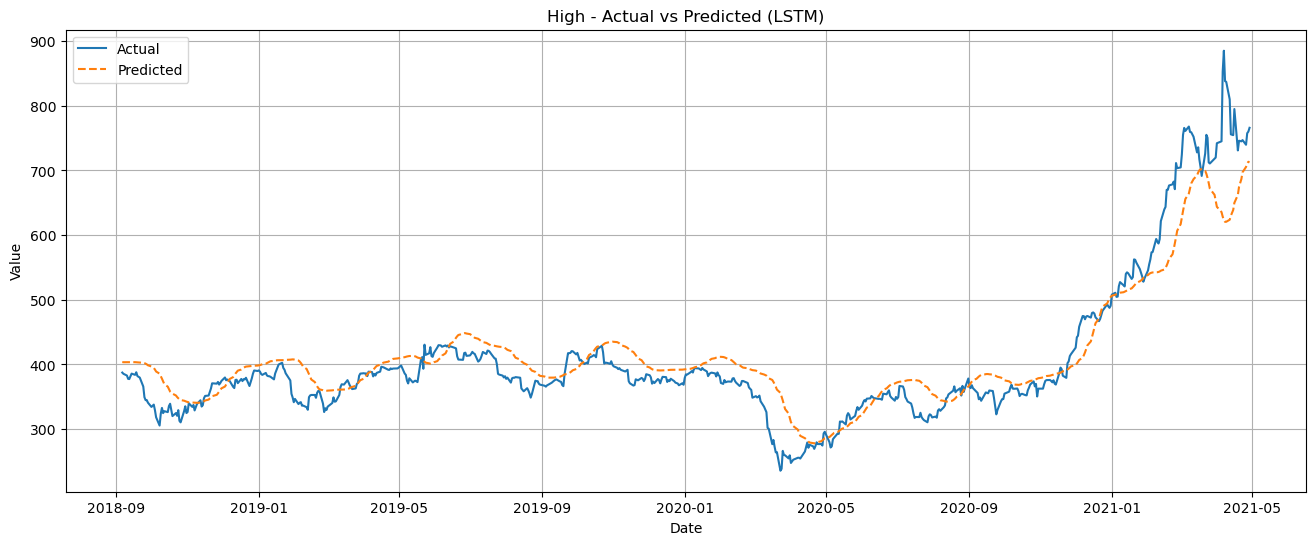

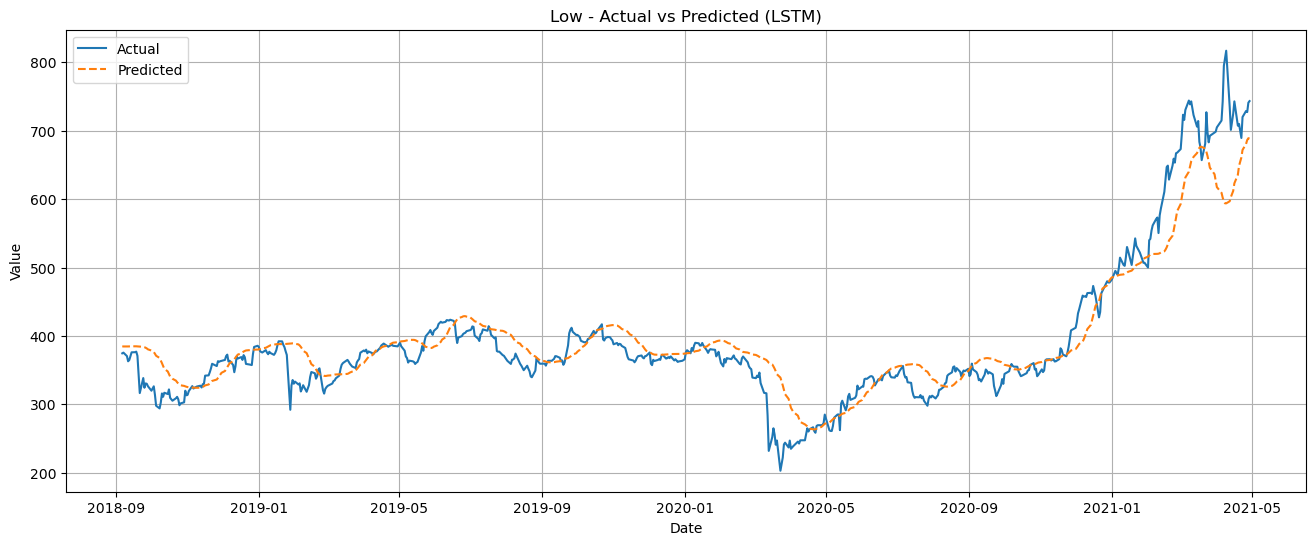

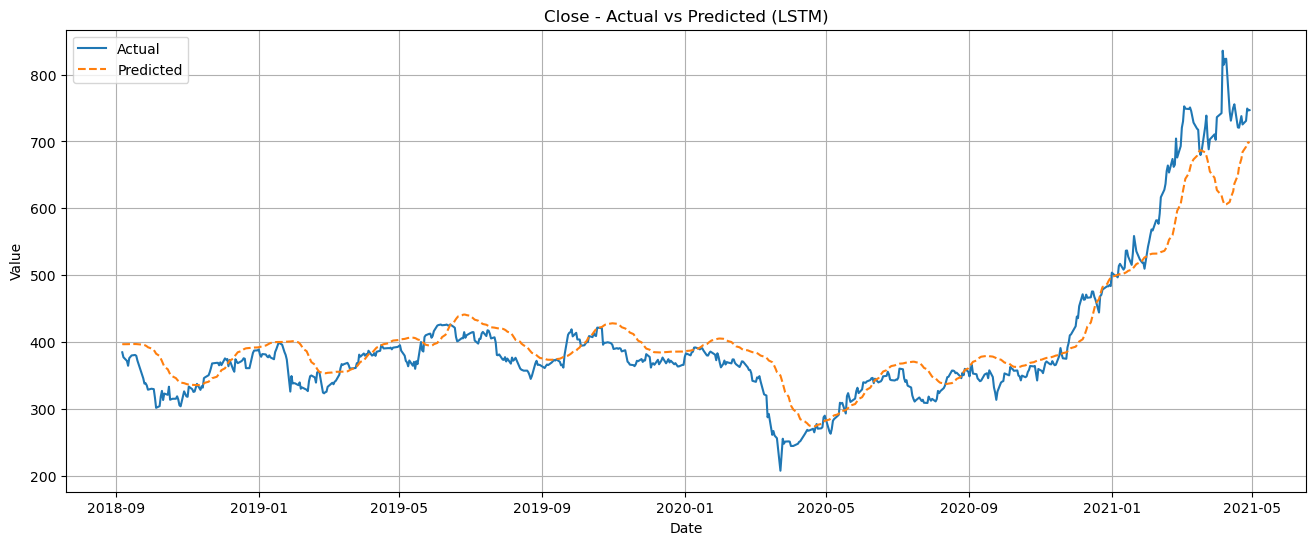

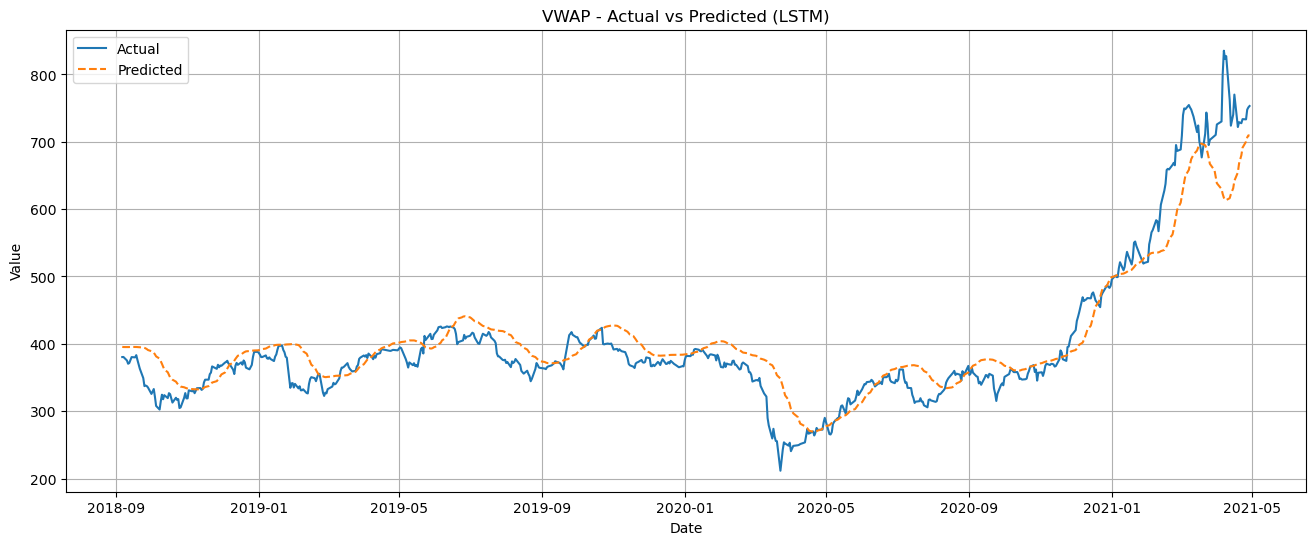

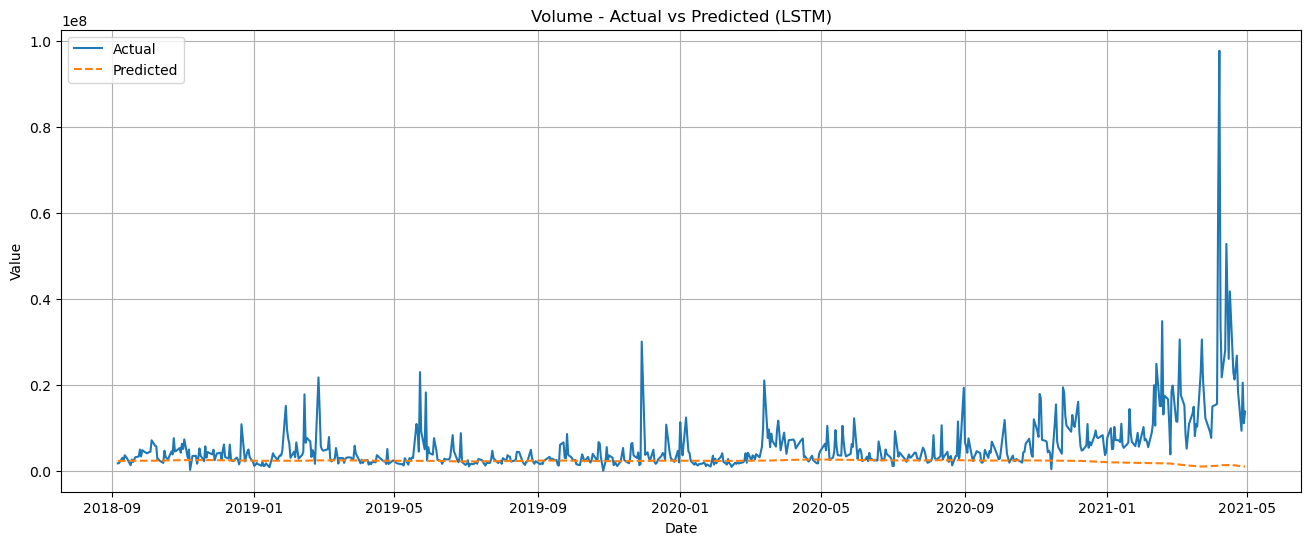

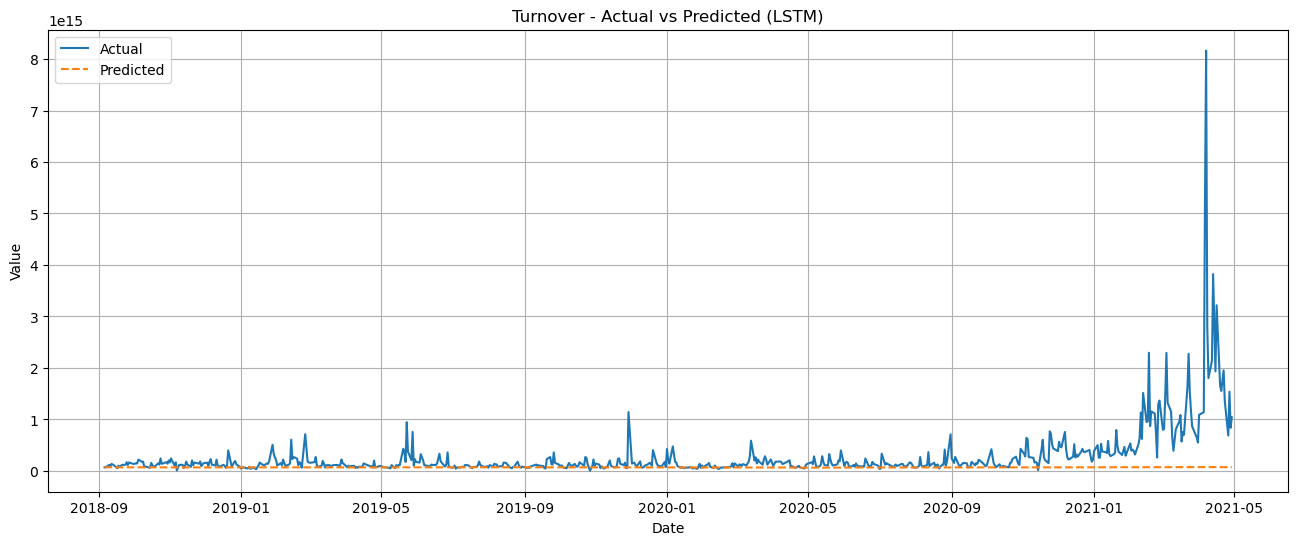

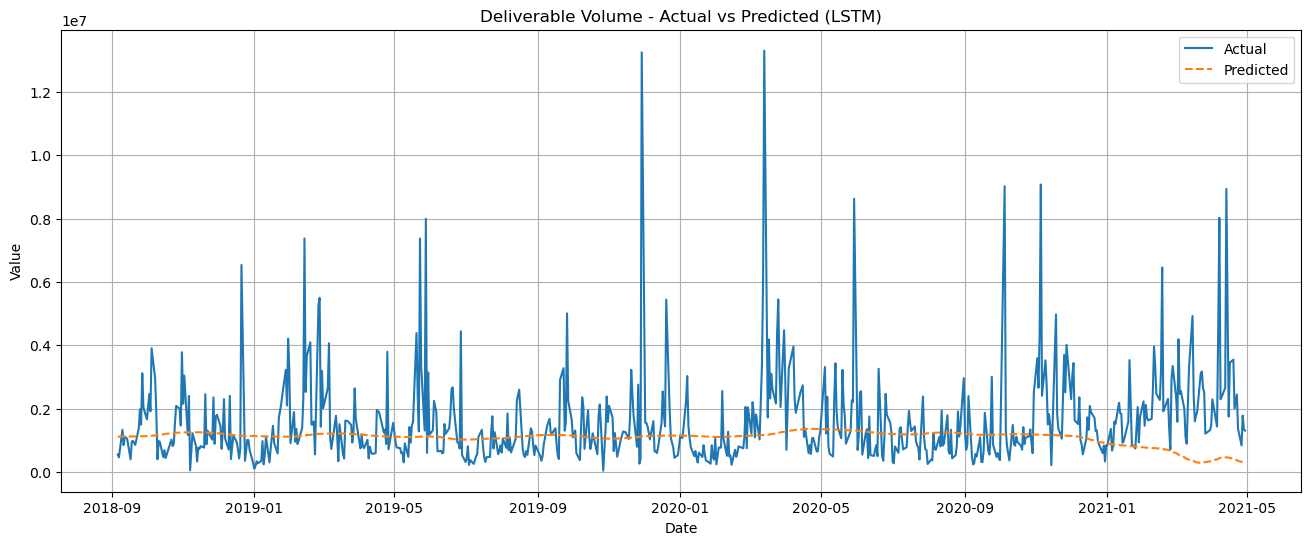

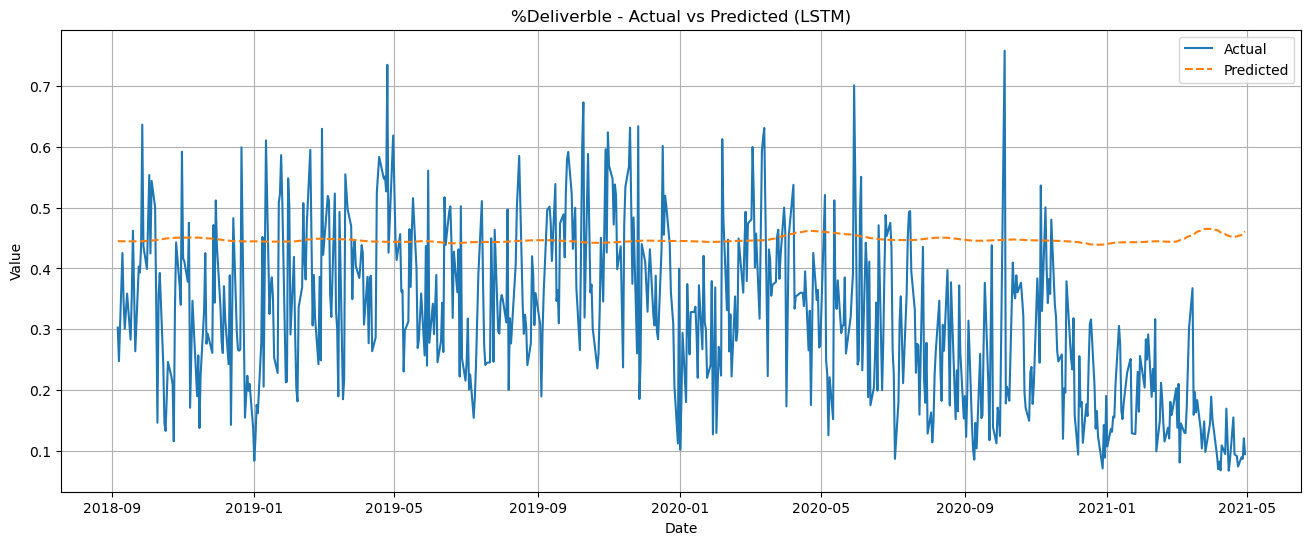

In [25]:
# Align predictions with actual data 
predicted_last_20 = pd.DataFrame(predictions[-num_samples: -1], columns=All_Columns, index=actual_last_20.index)

for columns in All_Columns:
    TimeSeriesPlot('LSTM', columns, predicted_last_20);

In [26]:
# Using RNN(Recurrent neural networks);model to predict 
RNNmodel = Sequential();
RNNmodel.add(Input(shape=(seq_length, len(All_Columns))));
RNNmodel.add(SimpleRNN(100, return_sequences=True))
RNNmodel.add(Dropout(0.3));
RNNmodel.add(SimpleRNN(100));
RNNmodel.add(Dropout(0.3));
RNNmodel.add(Dense(len(All_Columns)));
optimizer = Adam(learning_rate=0.001);

#Compile and fit the model
RNNmodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae']);
RNNmodel.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping]);

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.2182 - mae: 0.3588 - val_loss: 0.0083 - val_mae: 0.0692
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0412 - mae: 0.1573 - val_loss: 0.0037 - val_mae: 0.0409
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0218 - mae: 0.1121 - val_loss: 0.0031 - val_mae: 0.0339
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0148 - mae: 0.0914 - val_loss: 0.0027 - val_mae: 0.0315
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0112 - mae: 0.0780 - val_loss: 0.0026 - val_mae: 0.0274
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0093 - mae: 0.0698 - val_loss: 0.0026 - val_mae: 0.0268
Epoch 7/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0077 - mae: 0.0632 - val_loss: 0.0026 - val_mae: 0.0298
Epoch 8/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0067 - mae: 0.0586 - val_loss: 0.0023 - val_mae: 0.0235
Epoch 9/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

In [27]:
# Make predictions
RNNpredictions = RNNmodel.predict(X_test);
RNNpredictions = scaler.inverse_transform(RNNpredictions);

# Convert predictions to DataFrame 
predictions_df_RNN = pd.DataFrame(RNNpredictions, columns=All_Columns, index=df.index[-len(RNNpredictions):]);

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [28]:
# Print RNN predict result
printShapeResult(predictions_df_RNN);

Predicted Results:
            Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  394.727722  394.919952  403.776123  384.908813  397.092346   
2018-09-07  394.433411  394.611816  403.518372  384.661804  396.899597   
2018-09-10  394.338196  394.507172  403.448944  384.613708  396.892181   
2018-09-11  394.371674  394.537018  403.487061  384.688782  396.987701   
2018-09-12  394.460388  394.627777  403.561707  384.810486  397.109955   

                  VWAP      Volume      Turnover  Deliverable Volume  \
Date                                                                   
2018-09-06  395.534515  2397151.75  7.064347e+13         1113669.250   
2018-09-07  395.232544  2399971.50  7.060131e+13         1114792.125   
2018-09-10  395.135773  2402111.75  7.056206e+13         1115613.375   
2018-09-11  395.169159  2403519.00  7.053111e+13         1116229.125   
2018-09-12  395.258484  240431

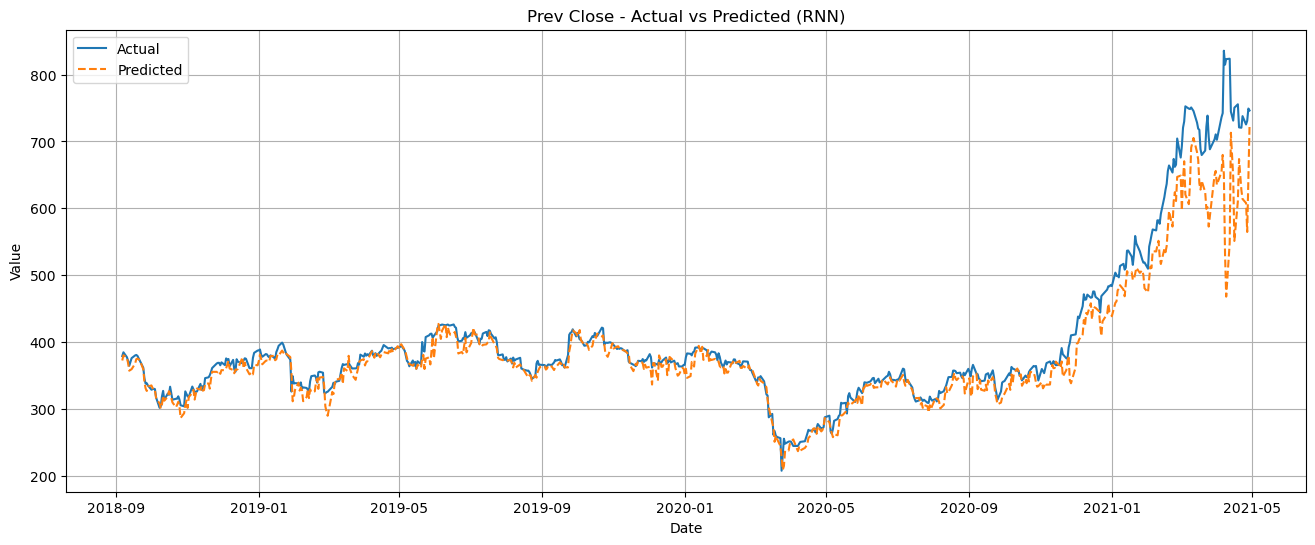

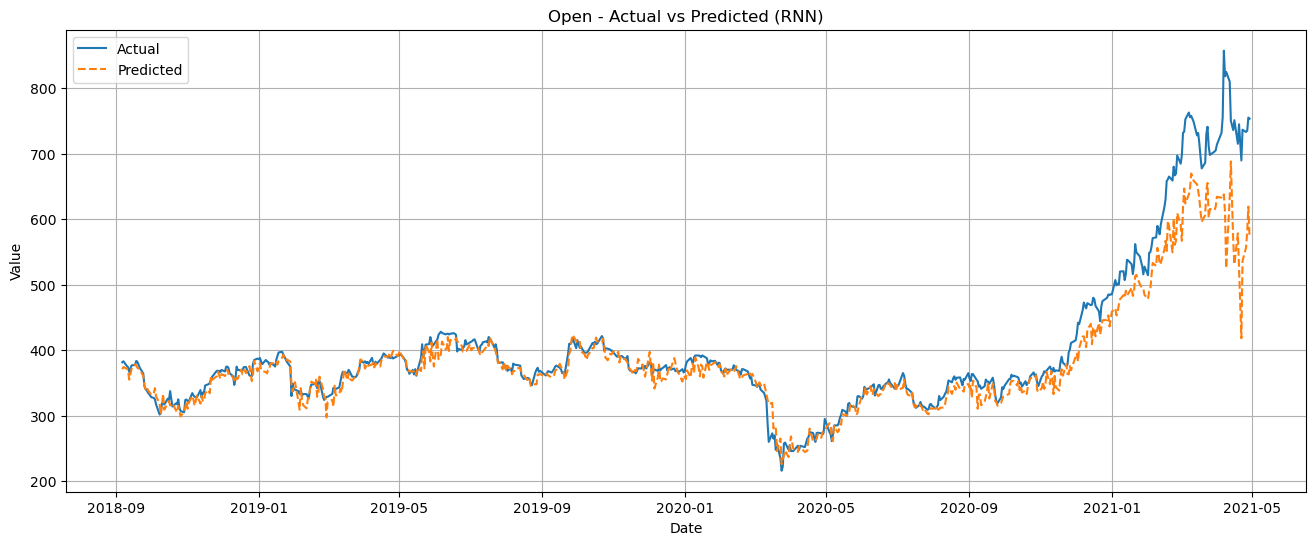

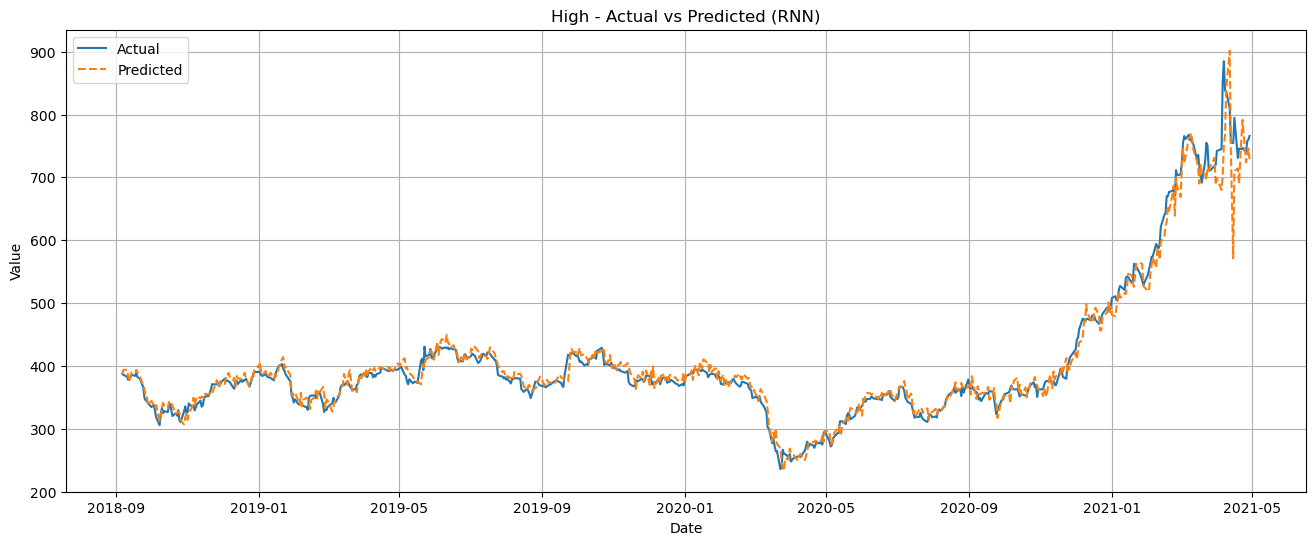

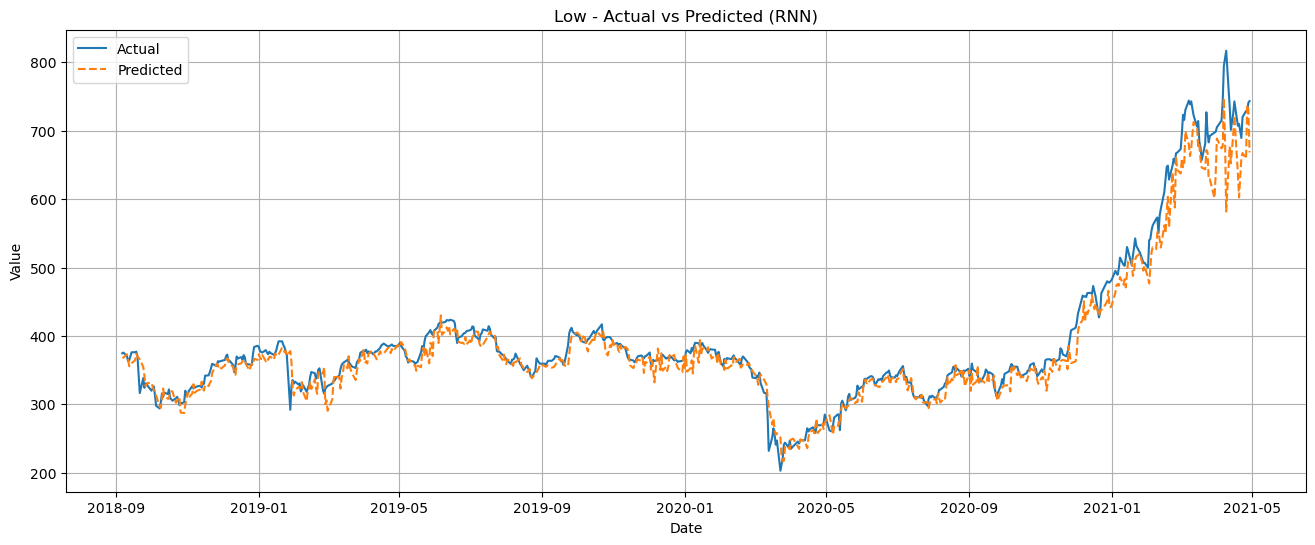

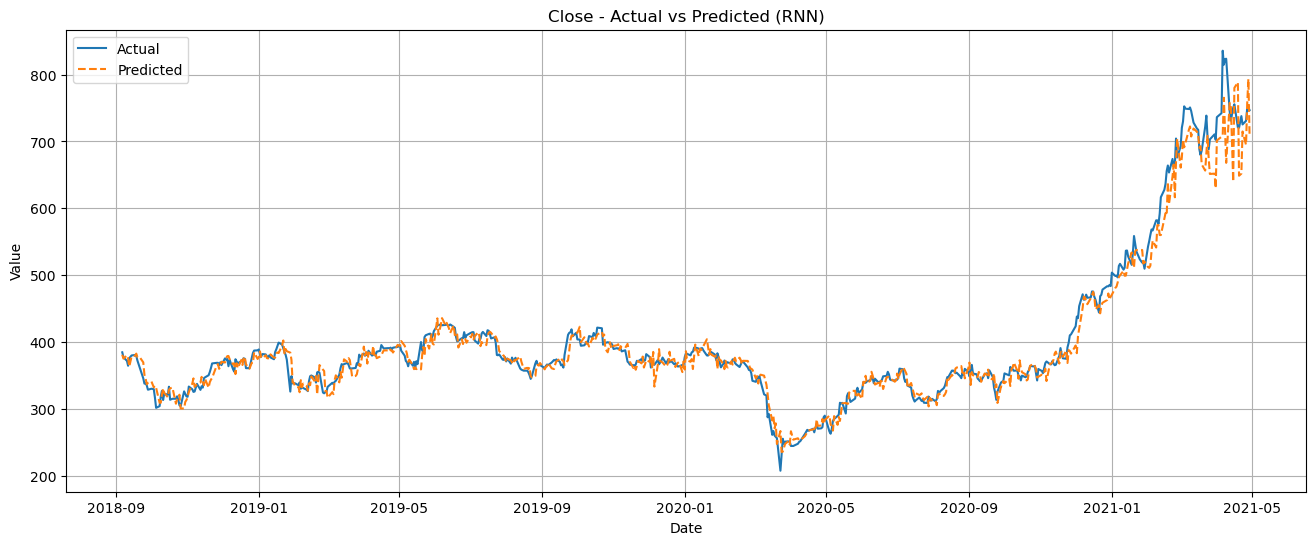

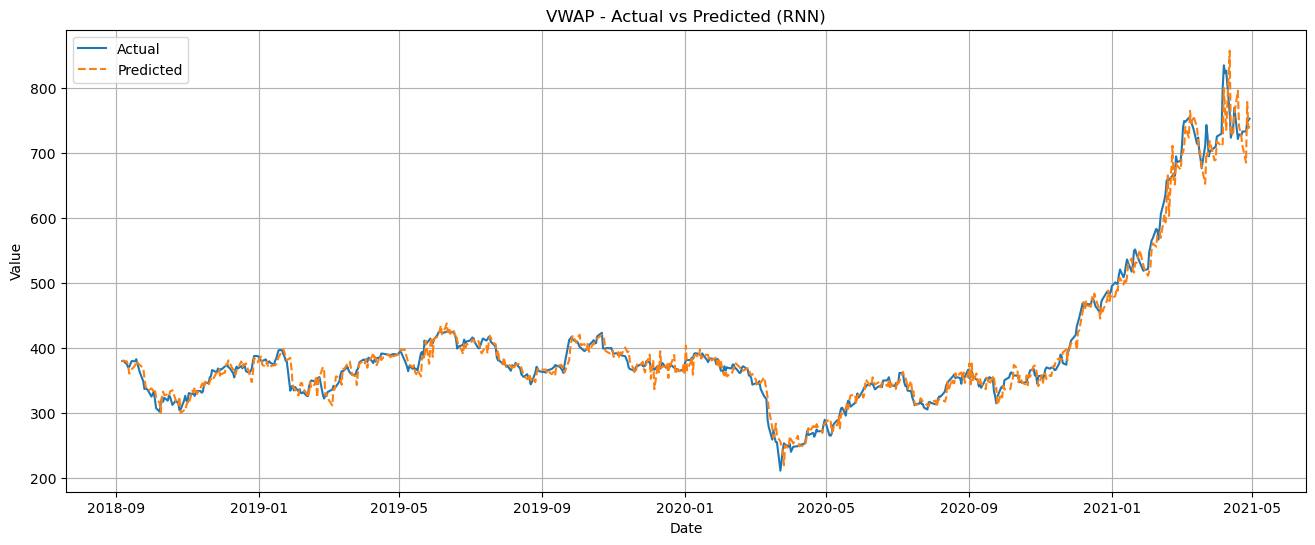

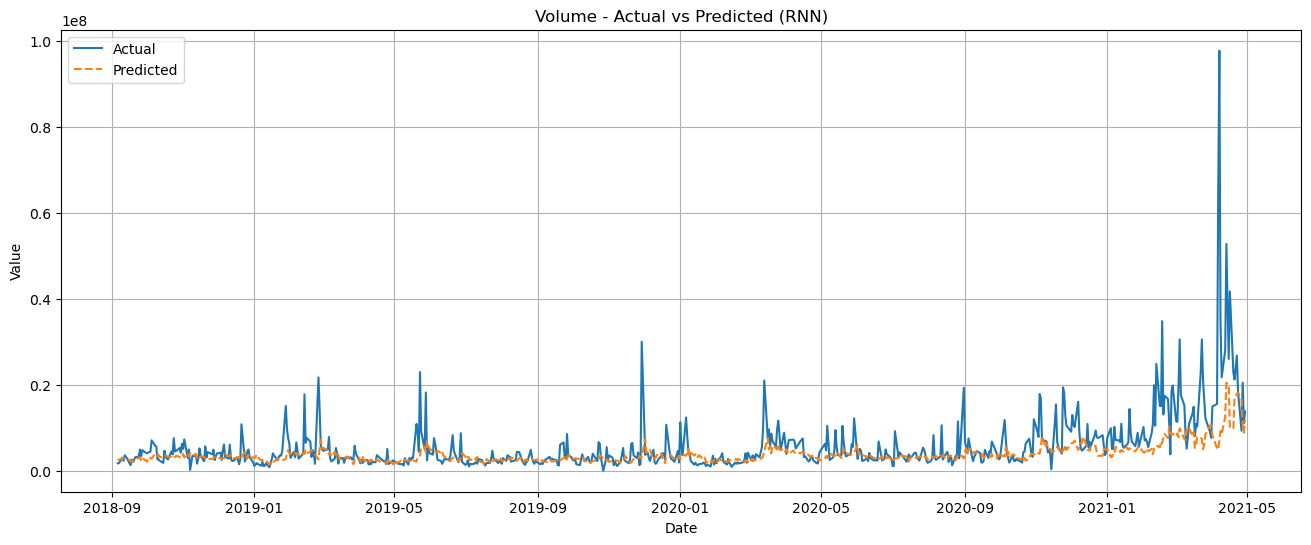

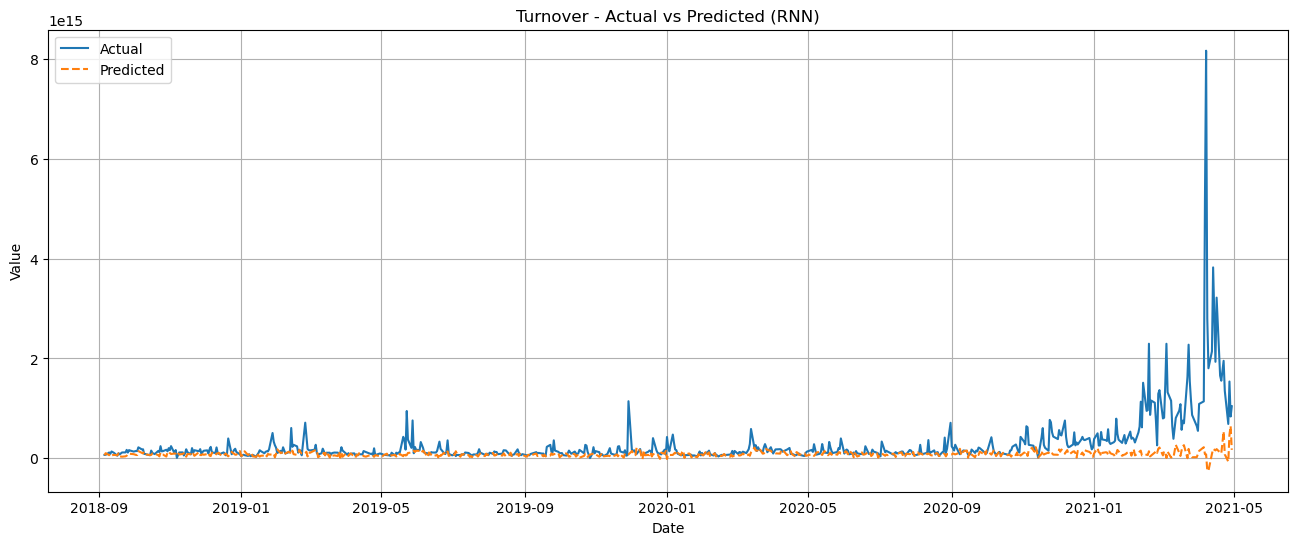

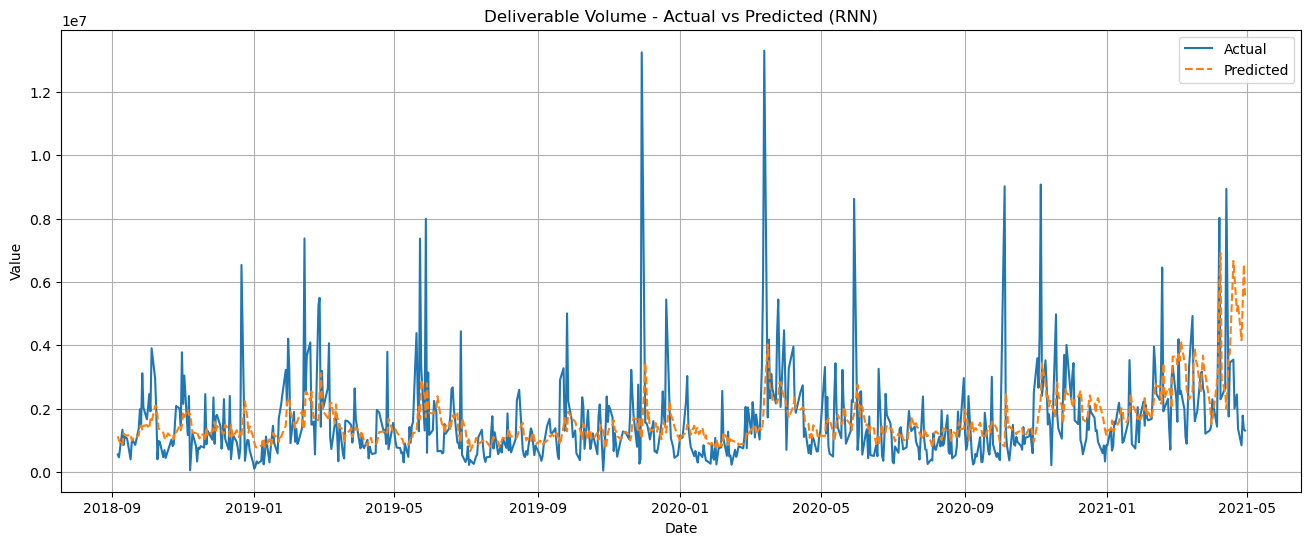

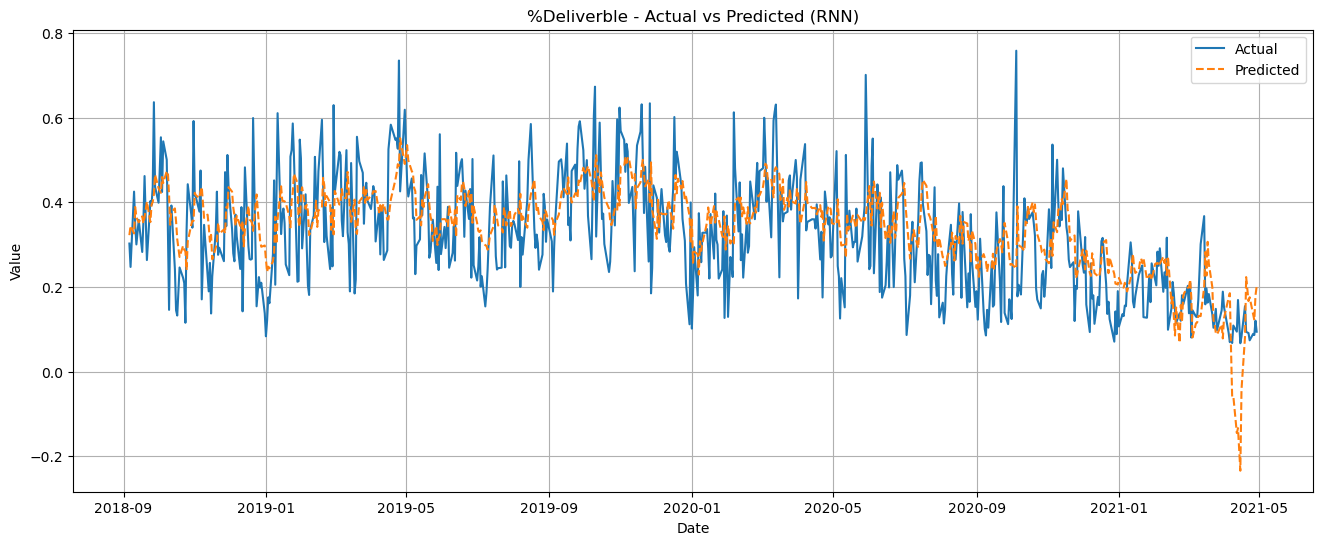

In [29]:
# Align predictions with actual data 
predicted_last_20_RNN = pd.DataFrame(RNNpredictions[-num_samples: -1], columns=All_Columns, index=actual_last_20.index);

for columns in All_Columns:
    TimeSeriesPlot('RNN', columns, predicted_last_20_RNN);

In [30]:
# using CNN (Convolutional Neural Networks);alogrithm to predict
CNNmodel = Sequential();
CNNmodel.add(Input(shape=(seq_length, len(All_Columns))));
CNNmodel.add(Conv1D(filters=64, kernel_size=2, activation='relu'));
CNNmodel.add(MaxPooling1D(pool_size=2));
CNNmodel.add(Flatten());
CNNmodel.add(Dense(100, activation='relu'));
CNNmodel.add(Dropout(0.3))
CNNmodel.add(Dense(100, activation='relu'));
CNNmodel.add(Dropout(0.3));
CNNmodel.add(Dense(len(All_Columns)));
optimizer = Adam(learning_rate=0.001);

#Compile and fit the model
CNNmodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae']);
CNNmodel.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping]);

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0298 - mae: 0.1172 - val_loss: 0.0039 - val_mae: 0.0399
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0088 - mae: 0.0641 - val_loss: 0.0033 - val_mae: 0.0333
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0075 - mae: 0.0567 - val_loss: 0.0038 - val_mae: 0.0375
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - mae: 0.0505 - val_loss: 0.0038 - val_mae: 0.0382
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 - mae: 0.0475 - val_loss: 0.0032 - val_mae: 0.0312
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - mae: 0.0446 - val_loss: 0.0035 - val_mae: 0.0356
Epoch 7/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050 - mae: 0.0445 - val_loss: 0.0030 - val_mae: 0.0305
Epoch 8/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046 - mae: 0.0422 - val_loss: 0.0029 - val_mae: 0.0285
Epoch 9/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.004

In [31]:
# Make predictions
CNNpredictions = CNNmodel.predict(X_test);
CNNpredictions = scaler.inverse_transform(CNNpredictions);

# Convert predictions to DataFrame 
predictions_df_CNN = pd.DataFrame(CNNpredictions, columns=All_Columns, index=df.index[-len(CNNpredictions):]);

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [32]:
# Print RNN predict result
printShapeResult(predictions_df_CNN);

Predicted Results:
            Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  394.727722  394.919952  403.776123  384.908813  397.092346   
2018-09-07  394.433411  394.611816  403.518372  384.661804  396.899597   
2018-09-10  394.338196  394.507172  403.448944  384.613708  396.892181   
2018-09-11  394.371674  394.537018  403.487061  384.688782  396.987701   
2018-09-12  394.460388  394.627777  403.561707  384.810486  397.109955   

                  VWAP      Volume      Turnover  Deliverable Volume  \
Date                                                                   
2018-09-06  395.534515  2397151.75  7.064347e+13         1113669.250   
2018-09-07  395.232544  2399971.50  7.060131e+13         1114792.125   
2018-09-10  395.135773  2402111.75  7.056206e+13         1115613.375   
2018-09-11  395.169159  2403519.00  7.053111e+13         1116229.125   
2018-09-12  395.258484  240431

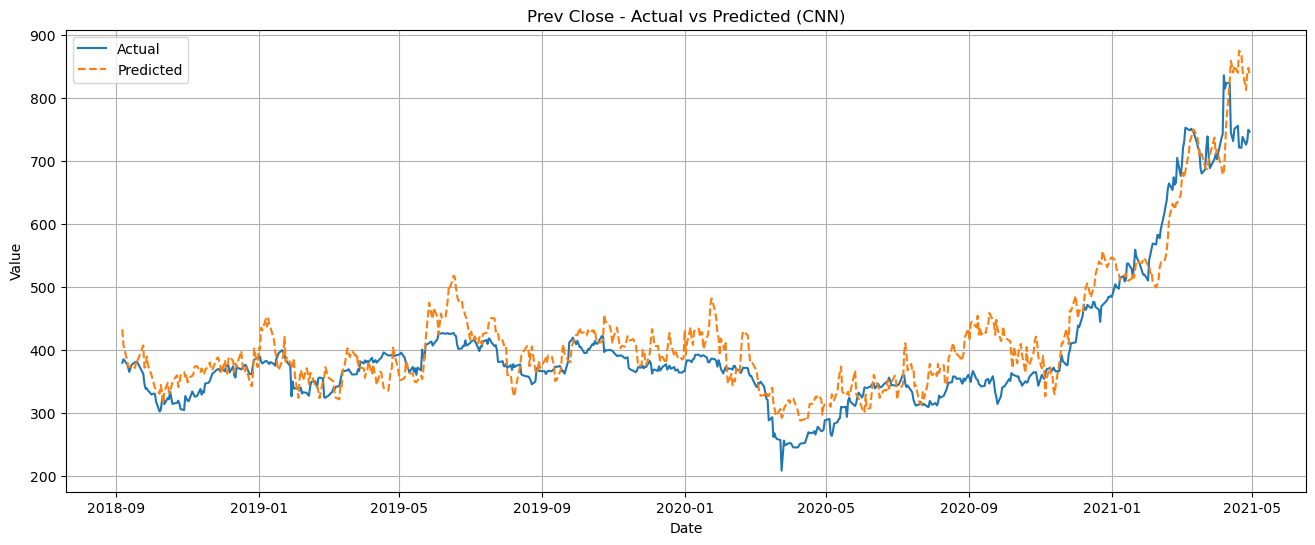

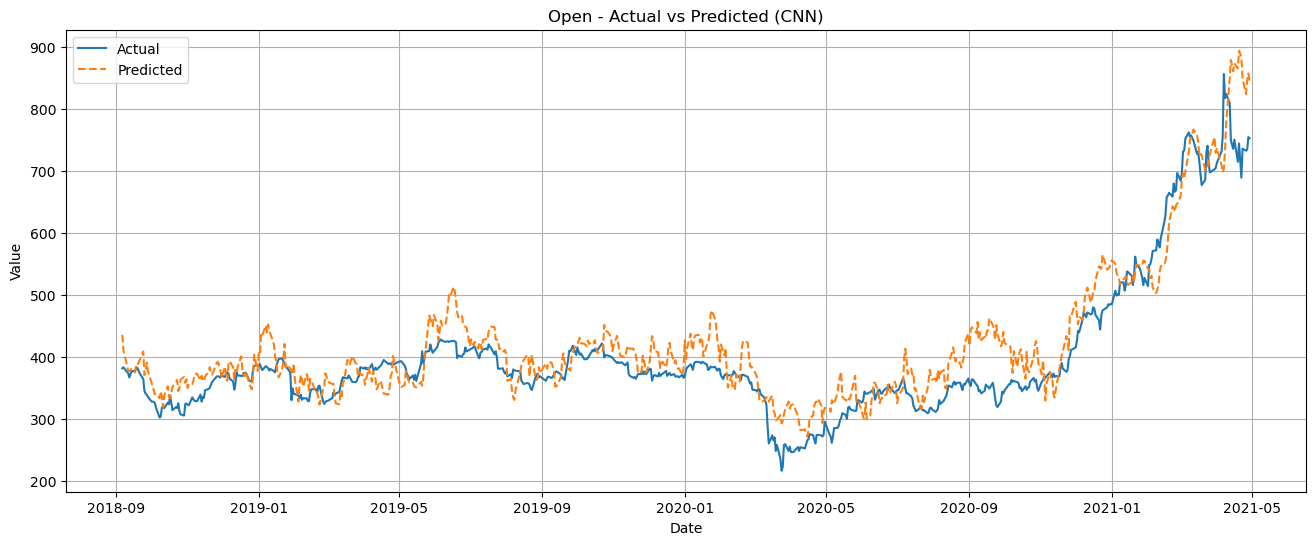

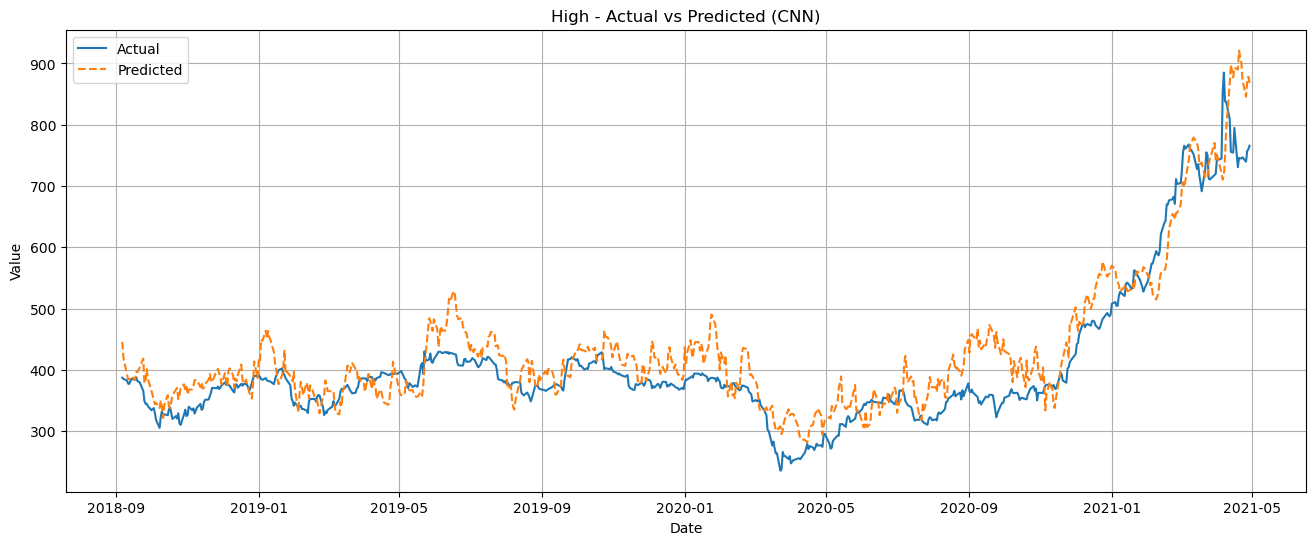

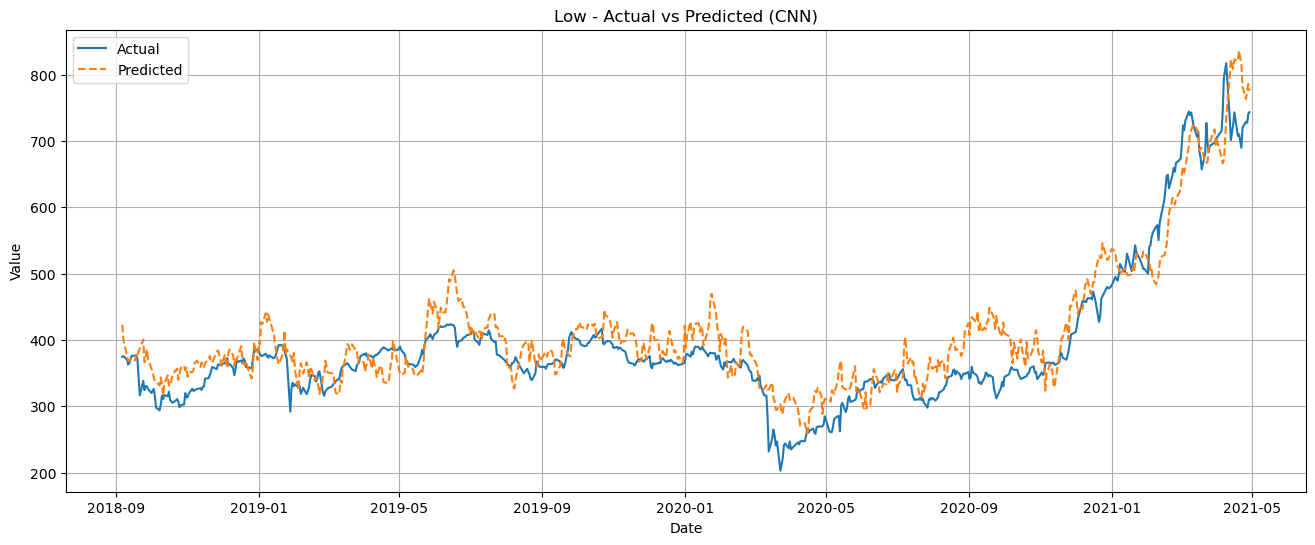

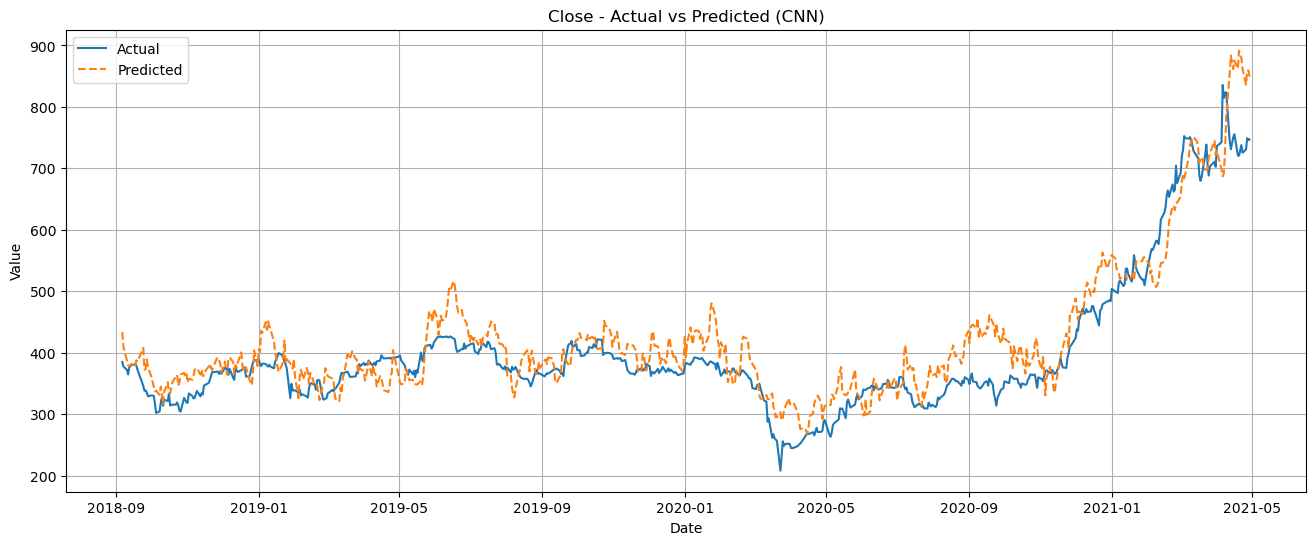

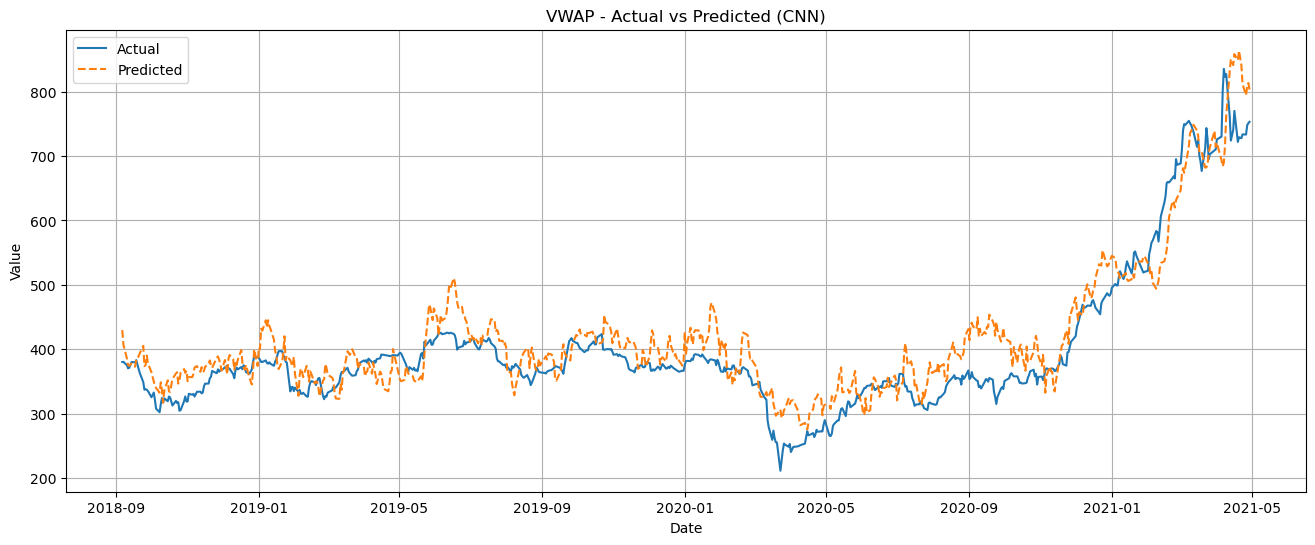

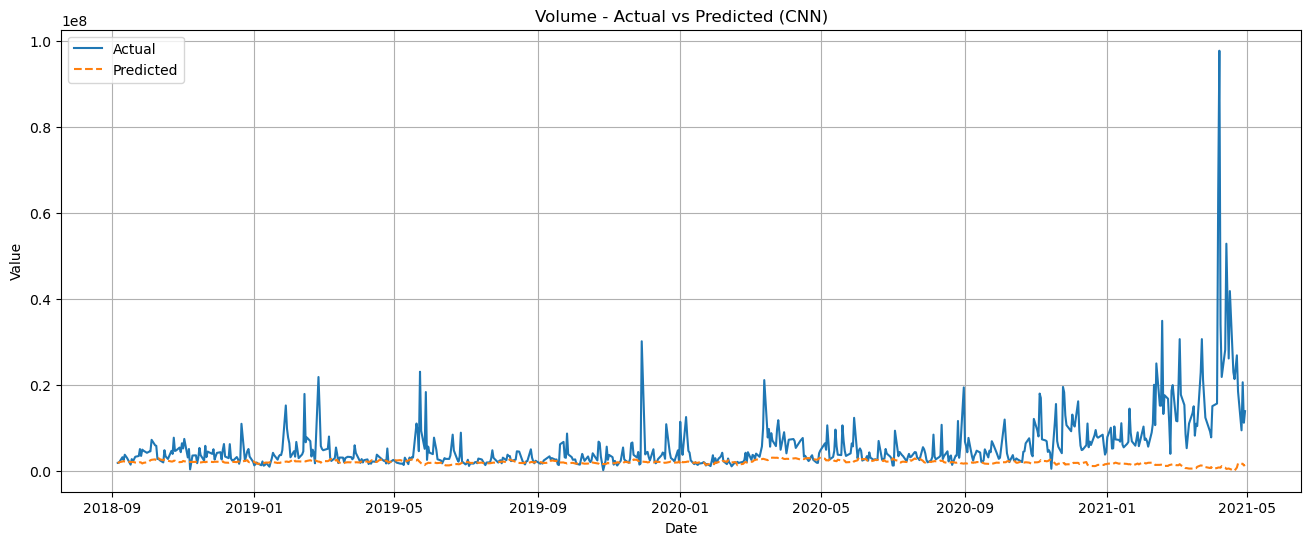

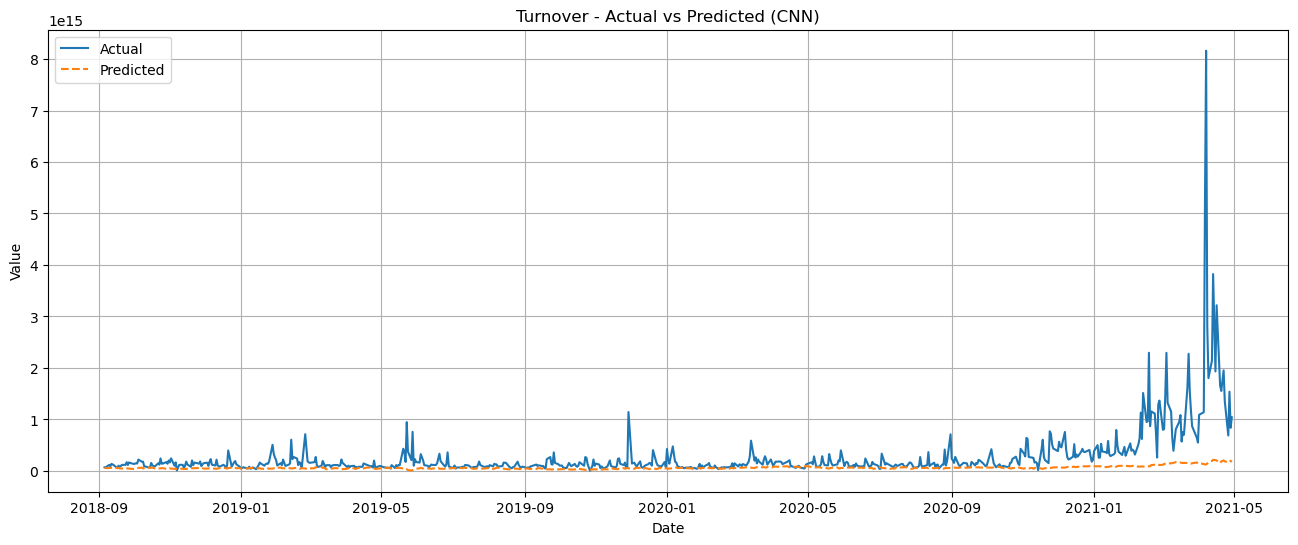

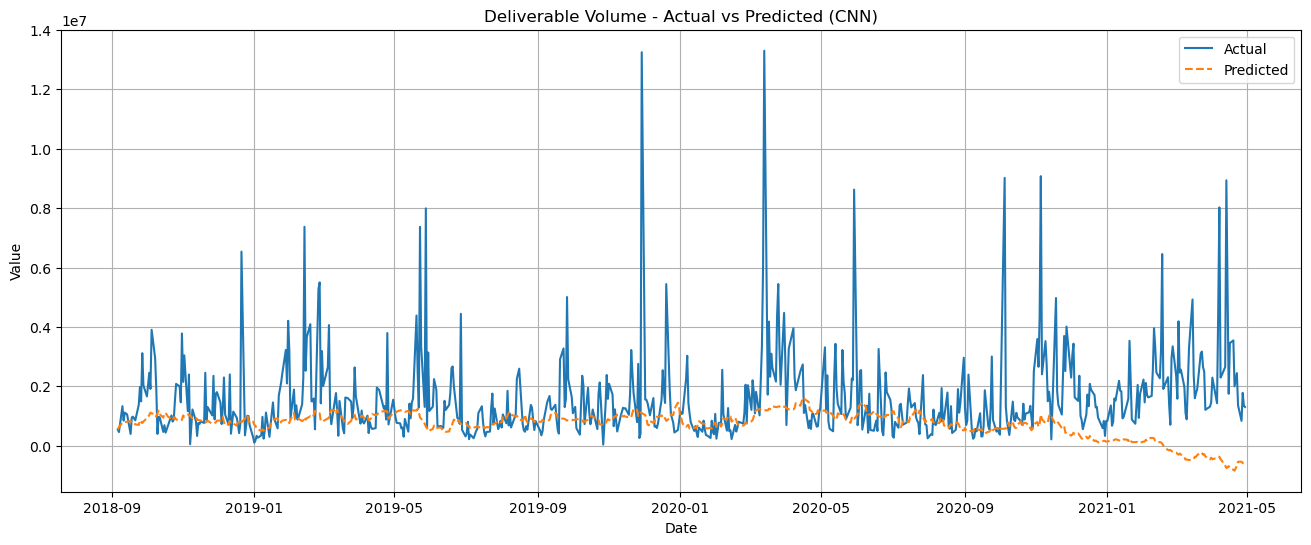

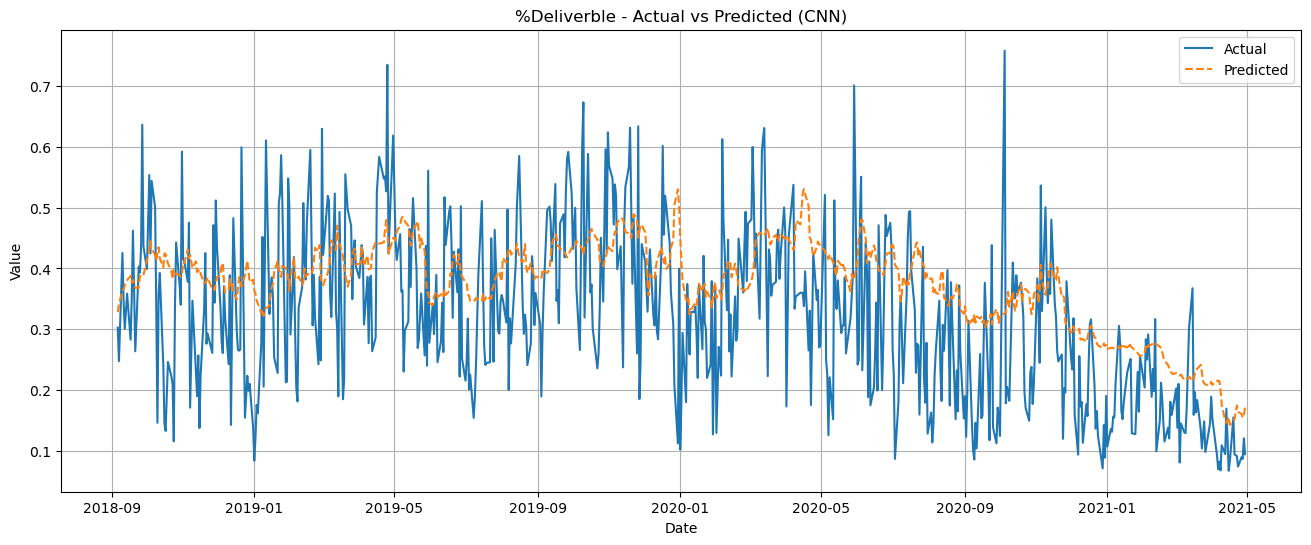

In [33]:
# Correct the slicing to include the last element
predicted_last_20_CNN = pd.DataFrame(CNNpredictions[-num_samples: -1], columns=All_Columns, index=actual_last_20.index);

# Print all the columns data with time series plot about the CNN result
for columns in All_Columns:
    TimeSeriesPlot('CNN', columns, predicted_last_20_CNN);

In [34]:
actual_df = actual_last_20;

DataFrameMap = {
    "Actual" : actual_df[All_Columns],
    "LSTM" : predictions_df[All_Columns],
    "RNN" : predictions_df_RNN[All_Columns],
    "CNN" : predictions_df_CNN[All_Columns]
}

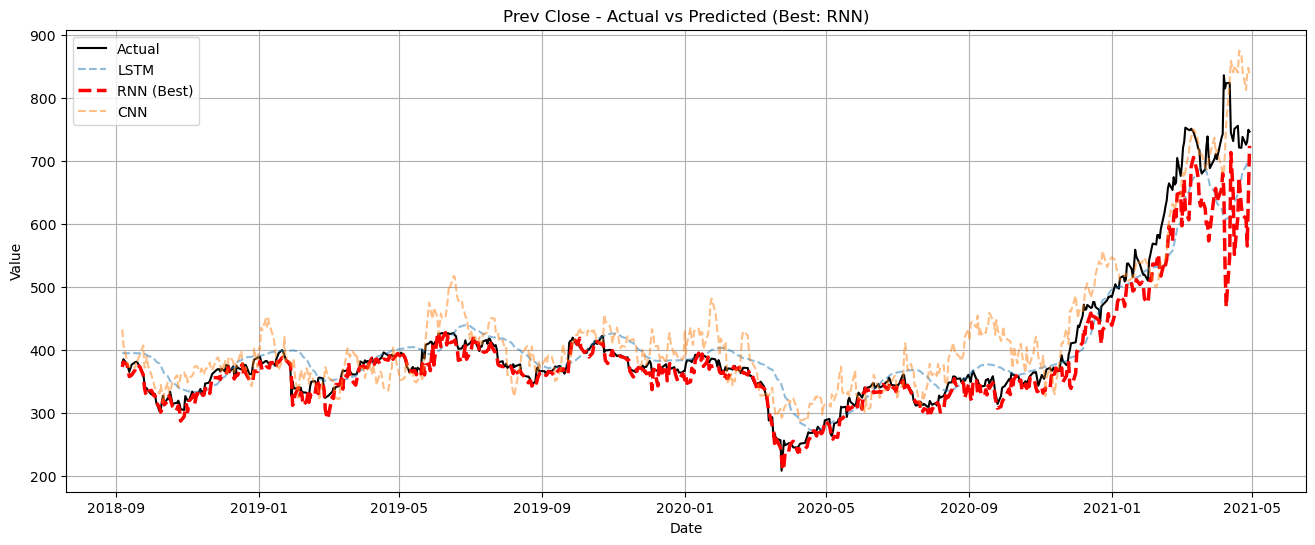

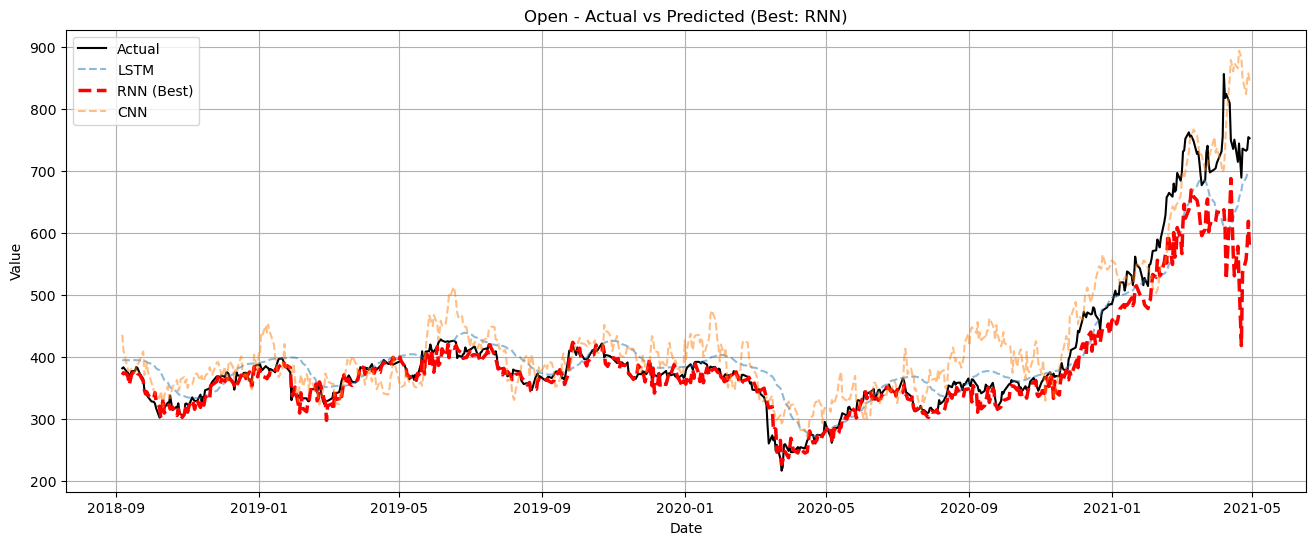

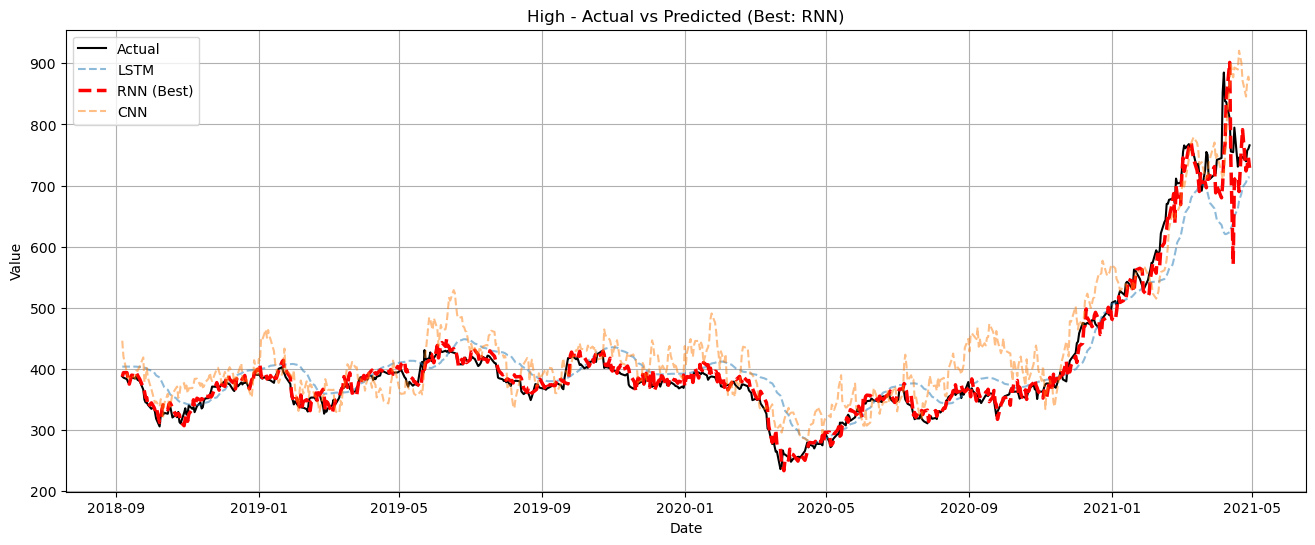

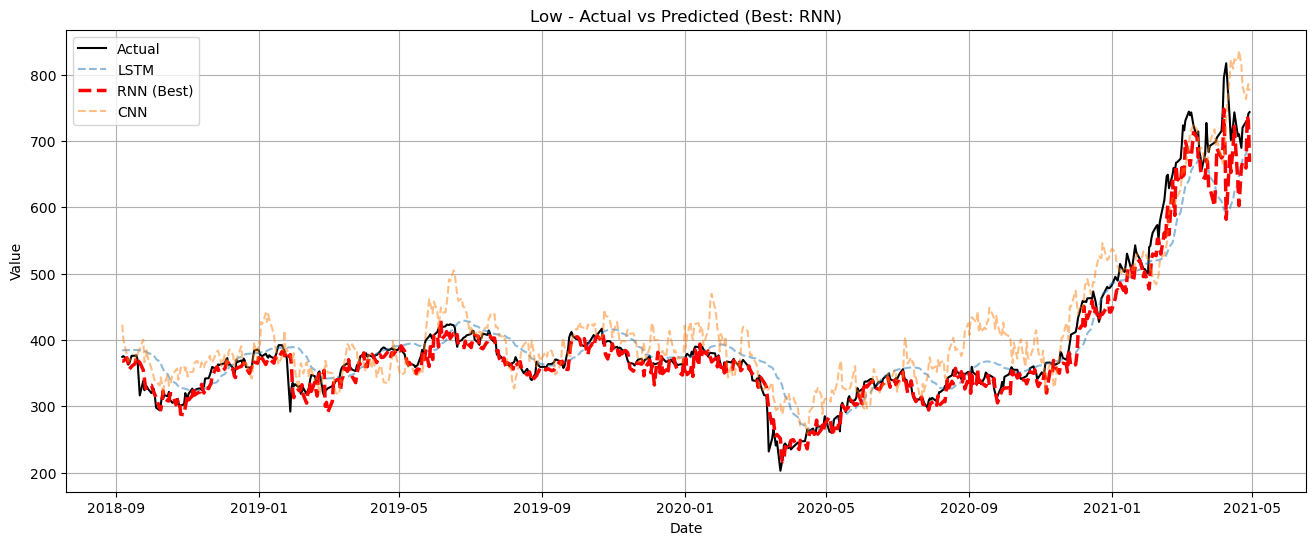

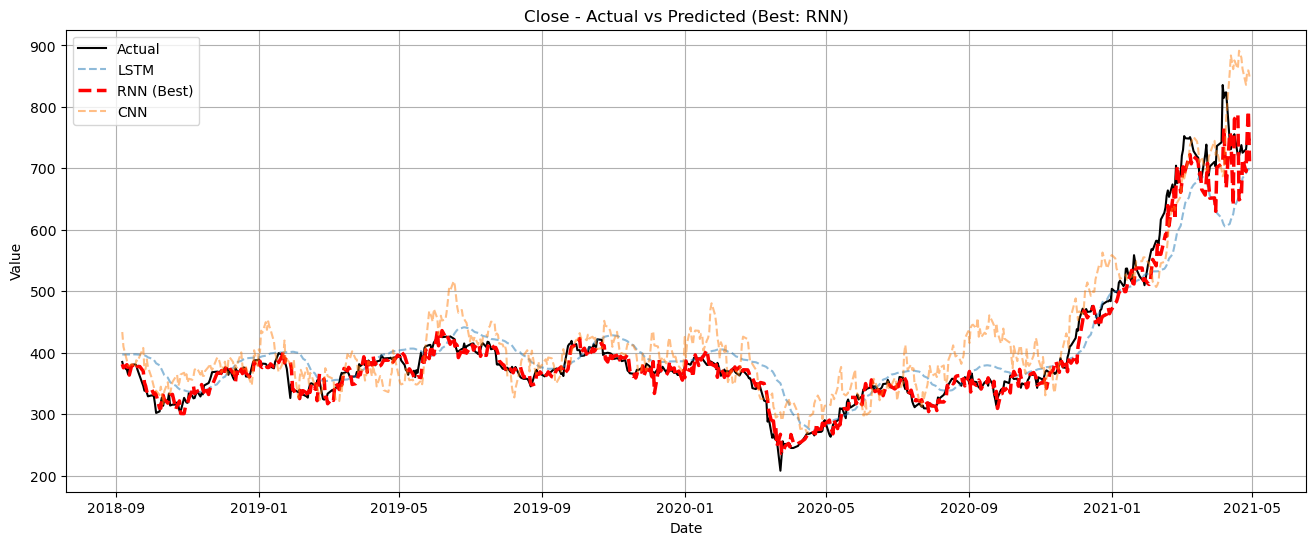

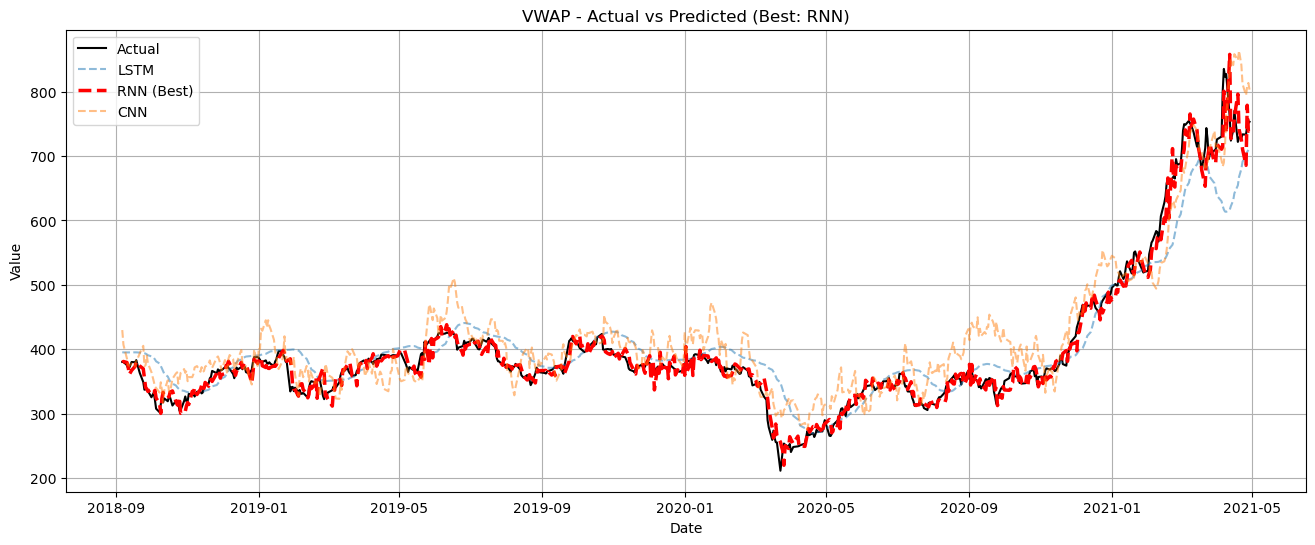

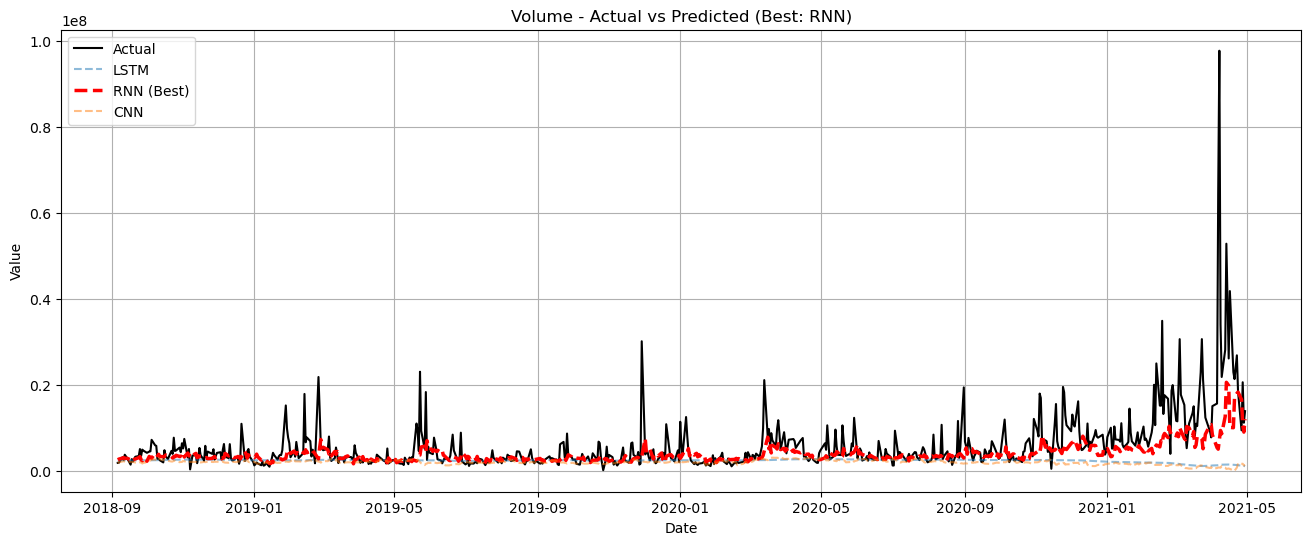

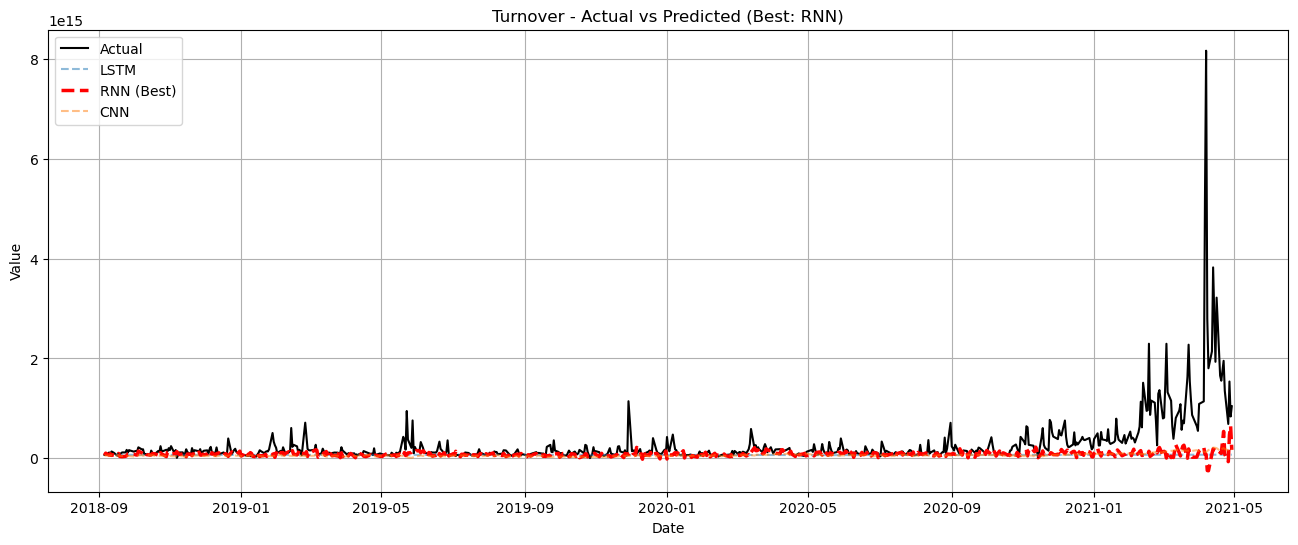

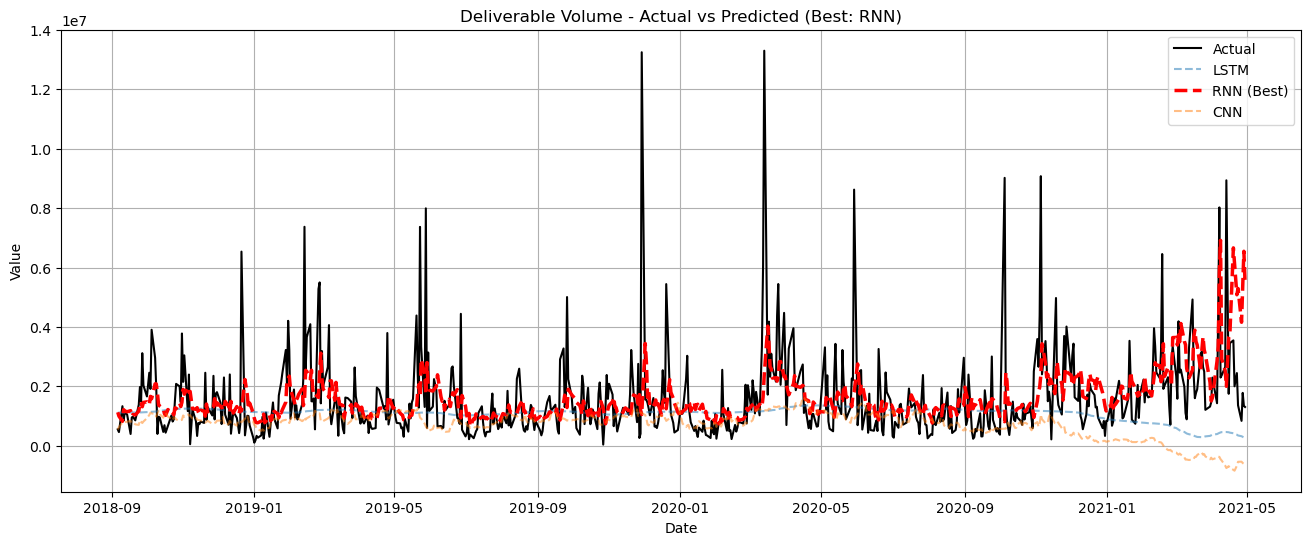

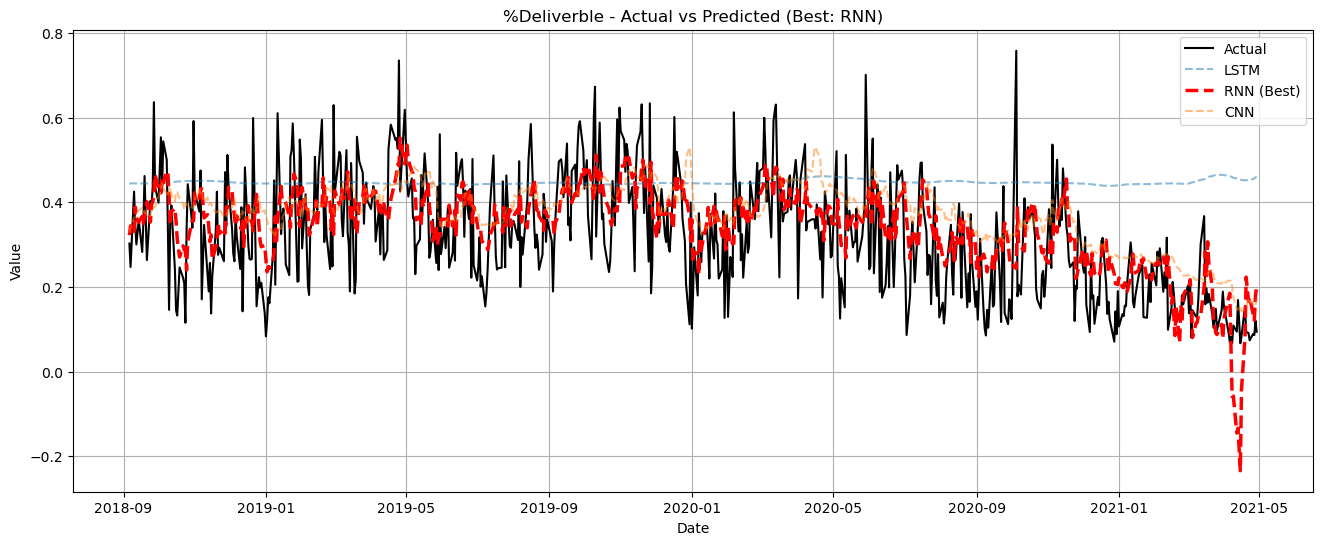

In [89]:
for columns in All_Columns:
    actual_series = DataFrameMap["Actual"][columns]
    
    model_data_map = {}
    mae_scores = {}
    
    for model_name, model_df in DataFrameMap.items():
        if model_name != "Actual":
            pred_series = model_df[columns]

            pred_series_aligned, actual_series_aligned = pred_series.align(actual_series, join='inner')

            model_data_map[model_name] = pred_series_aligned
            mae_scores[model_name] = mean_absolute_error(actual_series_aligned, pred_series_aligned)

    best_model_name = min(mae_scores, key=mae_scores.get)

    plot_time_series_all(actual_series, model_data_map, columns, best_model_name)

In [85]:
predictResults = [predicted_last_20, predicted_last_20_RNN, predicted_last_20_CNN];
path = "./PredictData/";
fileNames = ["RNN_PredictResult_Stock.csv", "LSTM_PredictResult_Stock.csv", "CNN_PredictResult_Stock.csv"]

for predictResult, fileName in zip(predictResults, fileNames):
    predictResult.to_csv(path + fileName, index="false");